<a href="https://colab.research.google.com/github/JuanCarlosAL91/deep-learning-2-TdeA/blob/main/Guia_13_Generacion_Texto_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guia 13: Generacion de Texto y Reconocimiento de Entidades (NER)
## Electiva II - Deep Learning | Tecnologico de Antioquia

---

**Objetivo:** Explorar las capacidades generativas de los modelos de lenguaje y aplicar Named Entity Recognition (NER) para extraer informacion estructurada de textos en espanol.

**Conceptos nuevos que aprenderemos:**
- Modelos generativos de texto y modelos autoregresivos (GPT)
- Parametros de generacion: `temperature`, `top_k`, `top_p`, `repetition_penalty`
- Named Entity Recognition (NER) y entidades nombradas (PER, ORG, LOC, MISC)
- Formato de etiquetado BIO (Begin, Inside, Outside)
- Pipelines encadenados: generacion + extraccion de informacion
- Modelos Seq2Seq (encoder-decoder)

**Prerrequisito:** Guia 12 - Analisis de Sentimiento Avanzado con Transformers

**Duracion estimada:** 3 horas

---

> **GPU obligatoria:** Este notebook requiere GPU para ejecutar los modelos de generacion y NER de manera eficiente. En Google Colab: *Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU (T4)*.

> **Evaluacion** ✍️: Las celdas marcadas con ✍️ son parte de la evaluacion. Debes responderlas con tus propias palabras de forma clara y argumentada.

---
## 1. Configuracion del Entorno

Instalamos las librerias necesarias y verificamos la disponibilidad de GPU.

In [34]:
# Instalacion de librerias necesarias
# transformers: modelos pre-entrenados de Hugging Face
# datasets: para cargar y manipular datasets
# accelerate: para optimizar el uso de GPU
!pip install transformers datasets accelerate -q

In [35]:
# Importacion de librerias
import torch
import numpy as np
import pandas as pd
import warnings
import json
import re
from collections import Counter, defaultdict

# Hugging Face
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForTokenClassification,
    set_seed
)

# Visualizacion
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Metricas
from sklearn.metrics import classification_report, confusion_matrix

# Configuracion general
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Librerias importadas correctamente")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers importado correctamente")

Librerias importadas correctamente
PyTorch version: 2.11.0+cu128
Transformers importado correctamente


In [36]:
# Verificacion de GPU
if torch.cuda.is_available():
    dispositivo = torch.device('cuda')
    nombre_gpu = torch.cuda.get_device_name(0)
    memoria_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU disponible: {nombre_gpu}")
    print(f"Memoria GPU total: {memoria_total:.1f} GB")
    print(f"Memoria GPU disponible: {torch.cuda.mem_get_alloc_retries()  if hasattr(torch.cuda, 'mem_get_alloc_retries') else 'N/A'}")
else:
    dispositivo = torch.device('cpu')
    print("ADVERTENCIA: No se detecto GPU. El notebook sera MUY lento.")
    print("Activa GPU en: Entorno de ejecucion > Cambiar tipo de entorno > GPU")

print(f"\nDispositivo seleccionado: {dispositivo}")

GPU disponible: Tesla T4
Memoria GPU total: 15.6 GB
Memoria GPU disponible: N/A

Dispositivo seleccionado: cuda


---
## 2. Marco Teorico

### 2.1 Modelos de Lenguaje: La Probabilidad de la Siguiente Palabra

Un **modelo de lenguaje** es un modelo estadistico que aprende la probabilidad de secuencias de palabras. Su tarea fundamental es predecir la siguiente palabra dado un contexto previo:

$$P(w_t | w_1, w_2, ..., w_{t-1})$$

Donde:
- $w_t$ es la palabra que queremos predecir
- $w_1, w_2, ..., w_{t-1}$ son las palabras anteriores (el contexto)

Por ejemplo, dado el contexto *"El gato se sento en el"*, un buen modelo de lenguaje asignaria alta probabilidad a palabras como *"sofa"*, *"piso"*, *"tejado"*, y baja probabilidad a palabras como *"azul"* o *"rapidamente"*.

La probabilidad de una secuencia completa se descompone como:

$$P(w_1, w_2, ..., w_n) = \prod_{t=1}^{n} P(w_t | w_1, ..., w_{t-1})$$

Los modelos de lenguaje modernos basados en Transformers aprenden estas distribuciones de probabilidad a partir de enormes cantidades de texto (miles de millones de palabras).

### 2.2 Arquitecturas de Transformers: Encoders vs Decoders vs Encoder-Decoder

En la Guia 11 aprendimos sobre Transformers. Ahora vamos a distinguir tres tipos de arquitectura:

| Caracteristica | Encoder (BERT/BETO) | Decoder (GPT) | Encoder-Decoder (T5, BART) |
|---|---|---|---|
| **Atencion** | Bidireccional | Unidireccional (causal) | Bidireccional + Unidireccional |
| **Tarea principal** | Entender texto | Generar texto | Transformar texto |
| **Ejemplos** | Clasificacion, NER, QA | Generacion, chatbots | Traduccion, resumen |
| **Pre-entrenamiento** | Masked Language Model | Next Token Prediction | Span corruption |
| **Modelos** | BERT, BETO, RoBERTa | GPT-2, GPT-3, LLaMA | T5, BART, mBART |

**Encoder (BERT/BETO):** Ve TODO el texto a la vez (bidireccional). Excelente para **entender** texto pero no puede generar texto nuevo. Es como un lector experto.

**Decoder (GPT):** Solo ve el texto anterior (unidireccional/causal). Genera texto **token por token**, prediciendo siempre la siguiente palabra. Es como un escritor.

**Encoder-Decoder (T5):** Tiene un encoder que lee todo el texto de entrada y un decoder que genera la salida. Es como un traductor: primero entiende y luego produce.

### 2.3 GPT y Modelos Autoregresivos

Los modelos **autoregresivos** generan texto de manera secuencial: producen un token a la vez, y cada token generado se anade al contexto para generar el siguiente.

```
Prompt:     "Colombia es un pais"
Paso 1:     "Colombia es un pais" -> "hermoso"
Paso 2:     "Colombia es un pais hermoso" -> "con"
Paso 3:     "Colombia es un pais hermoso con" -> "gran"
Paso 4:     "Colombia es un pais hermoso con gran" -> "biodiversidad"
...
```

**GPT-2** (Generative Pre-trained Transformer 2) es un modelo autoregresivo creado por OpenAI con 1.5 billones de parametros. Fue entrenado con texto de internet y puede generar texto coherente en multiples idiomas.

Para esta guia usaremos versiones de GPT-2 adaptadas al espanol, que fueron re-entrenadas (fine-tuned) con texto en nuestro idioma.

### 2.4 Parametros de Generacion de Texto

Cuando un modelo genera texto, en cada paso produce una **distribucion de probabilidad** sobre todo su vocabulario. Los parametros de generacion controlan **como se elige** el siguiente token de esa distribucion.

#### Temperature ($T$)

La temperature controla la "creatividad" o aleatoriedad de la generacion. Modifica los logits (valores antes del softmax) antes de calcular las probabilidades:

$$P(w_i) = \frac{\exp(z_i / T)}{\sum_{j} \exp(z_j / T)}$$

Donde:
- $z_i$ son los logits del modelo para el token $i$
- $T$ es la temperature

| Temperature | Efecto | Descripcion |
|---|---|---|
| $T \to 0$ | Determinista | Siempre elige el token mas probable (greedy) |
| $T = 1.0$ | Normal | Distribucion original del modelo |
| $T > 1.0$ | Mas creativo | Distribucion mas uniforme, mas aleatorio |

**Ejemplo visual:**

Si los logits son `[2.0, 1.0, 0.5]` para tres tokens:
- Con $T=0.1$: probabilidades $\approx [0.99, 0.01, 0.00]$ (casi siempre elige el primero)
- Con $T=1.0$: probabilidades $\approx [0.59, 0.24, 0.17]$ (distribucion normal)
- Con $T=2.0$: probabilidades $\approx [0.42, 0.31, 0.27]$ (mas uniforme)

#### Top-k Sampling

En lugar de considerar TODO el vocabulario (que puede tener 50,000+ tokens), el **top-k sampling** solo considera los **k tokens mas probables** y redistribuye la probabilidad entre ellos.

- `top_k=1`: Equivalente a greedy (solo el mas probable)
- `top_k=10`: Elige entre los 10 mas probables
- `top_k=50`: Elige entre los 50 mas probables (valor comun)

#### Top-p (Nucleus Sampling)

El **top-p sampling** (tambien llamado *nucleus sampling*) selecciona el conjunto mas pequeno de tokens cuya probabilidad acumulada sea mayor o igual a $p$:

$$\text{Seleccionar } V_p = \min\{V' \subseteq V : \sum_{w \in V'} P(w) \geq p\}$$

- `top_p=0.1`: Solo tokens que suman 10% de probabilidad (muy restrictivo)
- `top_p=0.9`: Tokens que suman 90% de probabilidad (valor comun)
- `top_p=1.0`: Todos los tokens (sin filtro)

**Ventaja sobre top-k:** Se adapta dinamicamente. Si el modelo esta muy seguro, selecciona pocos tokens. Si esta inseguro, selecciona mas.

#### Repetition Penalty

Penaliza tokens que ya aparecieron en el texto generado, reduciendo la repeticion:

$$z_i' = \begin{cases} z_i / \theta & \text{si } z_i > 0 \text{ y el token ya aparecio} \\ z_i \times \theta & \text{si } z_i < 0 \text{ y el token ya aparecio} \\ z_i & \text{en otro caso} \end{cases}$$

Donde $\theta$ es el factor de penalizacion (valores comunes: 1.0 a 2.0).

#### Beam Search vs Sampling

| Metodo | Descripcion | Uso ideal |
|---|---|---|
| **Greedy** | Siempre elige el token mas probable | Rapido pero poco diverso |
| **Beam Search** | Mantiene N mejores secuencias en paralelo | Traduccion, resumen |
| **Sampling** | Muestrea de la distribucion de probabilidad | Generacion creativa |
| **Sampling + filtros** | Sampling con top-k, top-p, temperature | Lo mas usado actualmente |

### 2.5 Named Entity Recognition (NER)

El **Reconocimiento de Entidades Nombradas** (NER, por *Named Entity Recognition*) es la tarea de identificar y clasificar entidades nombradas en un texto. Una **entidad nombrada** es una palabra o frase que se refiere a un objeto especifico del mundo real.

#### Tipos de Entidades

| Etiqueta | Tipo | Ejemplos |
|---|---|---|
| **PER** | Persona | Juan Perez, Gabriel Garcia Marquez, Shakira |
| **ORG** | Organizacion | Google, Universidad de Antioquia, Ecopetrol |
| **LOC** | Ubicacion | Medellin, Colombia, Rio Amazonas |
| **MISC** | Miscelaneo | Copa America, Bitcoin, idioma espanol |
| **DATE** | Fecha | 15 de marzo de 2024, ayer, siglo XXI |

#### Formato BIO (Begin-Inside-Outside)

El formato **BIO** es el esquema de etiquetado mas comun para NER:

- **B-XXX** (Begin): Primera palabra de una entidad de tipo XXX
- **I-XXX** (Inside): Palabras siguientes de la misma entidad
- **O** (Outside): Palabra que NO es parte de ninguna entidad

**Ejemplo:**

| Palabra | Etiqueta | Explicacion |
|---|---|---|
| Gabriel | B-PER | Inicio de entidad persona |
| Garcia | I-PER | Continuacion de entidad persona |
| Marquez | I-PER | Continuacion de entidad persona |
| nacio | O | No es entidad |
| en | O | No es entidad |
| Aracataca | B-LOC | Inicio de entidad ubicacion |
| , | O | No es entidad |
| Colombia | B-LOC | Inicio de entidad ubicacion |

#### NER con Transformers

Los modelos como BERT/BETO pueden ser ajustados (*fine-tuned*) para NER tratandolo como un problema de **clasificacion a nivel de token**: cada token recibe una etiqueta BIO.

```
Entrada:  [CLS] Gabriel Garcia Marquez nacio en Aracataca [SEP]
Salida:   [CLS] B-PER   I-PER   I-PER    O     O  B-LOC      [SEP]
```

### 2.6 Aplicaciones Reales

**Generacion de texto:**
- Chatbots y asistentes virtuales (ChatGPT, Bard)
- Autocompletado de codigo (GitHub Copilot)
- Generacion de contenido (articulos, correos, poesica)
- Resumen automatico de documentos
- Traduccion automatica

**Named Entity Recognition:**
- Extraccion de informacion de documentos legales, medicos, financieros
- Sistemas de busqueda y recomendacion
- Analisis automatico de noticias
- Construccion de grafos de conocimiento
- Anonimizacion de datos personales (detectar y ocultar nombres, direcciones)

**Pipelines combinados (Generacion + NER):**
- Generar resumen de un documento y extraer entidades clave
- Chatbots que extraen informacion estructurada de las respuestas del usuario
- Sistemas de preguntas y respuestas que identifican entidades en la respuesta

---

## 3. Preparacion de Datos

### 3.1 Dataset Anotado para NER

Creamos un dataset de oraciones en espanol con entidades anotadas manualmente. Este dataset contiene noticias simuladas sobre Colombia, deportes, tecnologia y cultura.

Cada oracion tiene sus tokens y las etiquetas BIO correspondientes.

In [37]:
# Dataset anotado manualmente para NER en espanol
# Cada entrada tiene: 'tokens' (lista de palabras) y 'ner_tags' (etiquetas BIO)
# Tipos de entidades: PER (persona), ORG (organizacion), LOC (ubicacion), MISC (miscelaneo)

dataset_ner = [
    # --- Noticias de Colombia ---
    {
        "tokens": ["Gustavo", "Petro", "anuncio", "nuevas", "reformas", "en", "Bogota"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["La", "alcaldesa", "de", "Medellin", "inauguro", "el", "nuevo", "metro"],
        "ner_tags": ["O", "O", "O", "B-LOC", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Ecopetrol", "reporto", "ganancias", "record", "en", "el", "tercer", "trimestre"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Gabriel", "Garcia", "Marquez", "nacio", "en", "Aracataca", ",", "Colombia"],
        "ner_tags": ["B-PER", "I-PER", "I-PER", "O", "O", "B-LOC", "O", "B-LOC"]
    },
    {
        "tokens": ["El", "Rio", "Amazonas", "atraviesa", "Leticia", "en", "el", "sur", "del", "pais"],
        "ner_tags": ["O", "B-LOC", "I-LOC", "O", "B-LOC", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["La", "Universidad", "de", "Antioquia", "celebro", "sus", "220", "anos"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "I-ORG", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Shakira", "ofrecio", "un", "concierto", "en", "Barranquilla"],
        "ner_tags": ["B-PER", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["El", "Banco", "de", "la", "Republica", "subio", "las", "tasas", "de", "interes"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "I-ORG", "I-ORG", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Cartagena", "recibio", "a", "miles", "de", "turistas", "en", "diciembre"],
        "ner_tags": ["B-LOC", "O", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Juan", "Manuel", "Santos", "recibio", "el", "Premio", "Nobel", "de", "la", "Paz"],
        "ner_tags": ["B-PER", "I-PER", "I-PER", "O", "O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "I-MISC"]
    },
    # --- Deportes ---
    {
        "tokens": ["James", "Rodriguez", "ficho", "por", "el", "Rayo", "Vallecano"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-ORG", "I-ORG"]
    },
    {
        "tokens": ["La", "Seleccion", "Colombia", "gano", "la", "Copa", "America"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["Egan", "Bernal", "triunfo", "en", "el", "Tour", "de", "Francia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-MISC", "I-MISC", "I-MISC"]
    },
    {
        "tokens": ["Atletico", "Nacional", "es", "campeon", "de", "la", "Liga", "BetPlay"],
        "ner_tags": ["B-ORG", "I-ORG", "O", "O", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["Caterine", "Ibarguen", "gano", "oro", "en", "los", "Juegos", "Olimpicos"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["Millonarios", "derroto", "a", "Santa", "Fe", "en", "el", "Campin"],
        "ner_tags": ["B-ORG", "O", "O", "B-ORG", "I-ORG", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Nairo", "Quintana", "compitio", "en", "el", "Giro", "de", "Italia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-MISC", "I-MISC", "I-MISC"]
    },
    {
        "tokens": ["El", "Deportivo", "Cali", "descendio", "a", "la", "segunda", "division"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Radamel", "Falcao", "es", "el", "goleador", "historico", "de", "Colombia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["La", "FIFA", "eligio", "a", "Barranquilla", "como", "sede", "del", "Mundial"],
        "ner_tags": ["O", "B-ORG", "O", "O", "B-LOC", "O", "O", "O", "B-MISC"]
    },
    # --- Tecnologia ---
    {
        "tokens": ["Google", "abrio", "oficinas", "en", "Bogota", "para", "toda", "Latinoamerica"],
        "ner_tags": ["B-ORG", "O", "O", "O", "B-LOC", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Rappi", "fue", "fundada", "en", "Colombia", "por", "Simon", "Borrero"],
        "ner_tags": ["B-ORG", "O", "O", "O", "B-LOC", "O", "B-PER", "I-PER"]
    },
    {
        "tokens": ["Microsoft", "lanzo", "una", "nueva", "version", "de", "Windows"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "O", "B-MISC"]
    },
    {
        "tokens": ["Elon", "Musk", "compro", "Twitter", "por", "44", "mil", "millones"],
        "ner_tags": ["B-PER", "I-PER", "O", "B-ORG", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Apple", "presento", "el", "iPhone", "en", "California"],
        "ner_tags": ["B-ORG", "O", "O", "B-MISC", "O", "B-LOC"]
    },
    {
        "tokens": ["El", "Tecnologico", "de", "Antioquia", "ofrece", "programas", "de", "inteligencia", "artificial"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "I-ORG", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Samsung", "inauguro", "una", "fabrica", "en", "Manizales"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Amazon", "expande", "sus", "servicios", "en", "Cali", "y", "Medellin"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "B-LOC", "O", "B-LOC"]
    },
    {
        "tokens": ["Meta", "desarrollo", "un", "modelo", "de", "lenguaje", "llamado", "LLaMA"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "O", "O", "B-MISC"]
    },
    {
        "tokens": ["OpenAI", "creo", "ChatGPT", "en", "San", "Francisco"],
        "ner_tags": ["B-ORG", "O", "B-MISC", "O", "B-LOC", "I-LOC"]
    },
    # --- Cultura y sociedad ---
    {
        "tokens": ["El", "Carnaval", "de", "Barranquilla", "es", "Patrimonio", "de", "la", "Humanidad"],
        "ner_tags": ["O", "B-MISC", "I-MISC", "I-MISC", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Fernando", "Botero", "expuso", "sus", "obras", "en", "el", "Museo", "de", "Antioquia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "O", "B-ORG", "I-ORG", "I-ORG"]
    },
    {
        "tokens": ["La", "Feria", "de", "las", "Flores", "se", "celebra", "en", "Medellin"],
        "ner_tags": ["O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Carlos", "Vives", "canto", "en", "el", "Festival", "Vallenato"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["Juanes", "gano", "un", "Grammy", "Latino", "en", "Las", "Vegas"],
        "ner_tags": ["B-PER", "O", "O", "B-MISC", "I-MISC", "O", "B-LOC", "I-LOC"]
    },
    {
        "tokens": ["La", "Universidad", "Nacional", "de", "Colombia", "tiene", "sede", "en", "Bogota"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "I-ORG", "I-ORG", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Mariana", "Pajon", "gano", "medalla", "de", "oro", "en", "BMX"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "O", "B-MISC"]
    },
    {
        "tokens": ["El", "cafe", "colombiano", "se", "exporta", "a", "Europa", "y", "Asia"],
        "ner_tags": ["O", "O", "O", "O", "O", "O", "B-LOC", "O", "B-LOC"]
    },
    {
        "tokens": ["J", "Balvin", "presento", "su", "nuevo", "album", "en", "Nueva", "York"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "O", "B-LOC", "I-LOC"]
    },
    {
        "tokens": ["El", "Festival", "de", "Cine", "de", "Cartagena", "celebro", "su", "edicion", "63"],
        "ner_tags": ["O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "I-MISC", "O", "O", "O", "O"]
    },
    # --- Politica y economia ---
    {
        "tokens": ["El", "Congreso", "de", "Colombia", "aprobo", "la", "reforma", "tributaria"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "I-ORG", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Francia", "Marquez", "es", "la", "vicepresidenta", "de", "Colombia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Bancolombia", "adquirio", "un", "banco", "en", "Guatemala"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["El", "peso", "colombiano", "se", "deprecio", "frente", "al", "dolar"],
        "ner_tags": ["O", "O", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["La", "Corte", "Constitucional", "emitio", "un", "fallo", "historico"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Sergio", "Fajardo", "fue", "alcalde", "de", "Medellin", "y", "gobernador", "de", "Antioquia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-LOC", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Bavaria", "invirtio", "en", "una", "planta", "en", "Tocancipa"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Avianca", "es", "la", "aerolinea", "mas", "antigua", "de", "America"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["El", "DANE", "publico", "los", "resultados", "del", "censo", "nacional"],
        "ner_tags": ["O", "B-ORG", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["La", "ANDI", "presento", "un", "informe", "sobre", "la", "economia", "en", "Colombia"],
        "ner_tags": ["O", "B-ORG", "O", "O", "O", "O", "O", "O", "O", "B-LOC"]
    },
    # --- Mas oraciones variadas ---
    {
        "tokens": ["Claudia", "Lopez", "impulso", "el", "TransMilenio", "en", "Bogota"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "B-ORG", "O", "B-LOC"]
    },
    {
        "tokens": ["El", "volcan", "Nevado", "del", "Ruiz", "esta", "en", "Caldas"],
        "ner_tags": ["O", "O", "B-LOC", "I-LOC", "I-LOC", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["La", "Guajira", "enfrenta", "problemas", "de", "sequia"],
        "ner_tags": ["O", "B-LOC", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Isabel", "Allende", "presento", "su", "libro", "en", "la", "Feria", "del", "Libro", "de", "Bogota"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "O", "O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "I-MISC"]
    },
    {
        "tokens": ["Pasto", "fue", "nombrada", "capital", "de", "la", "cultura"],
        "ner_tags": ["B-LOC", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["SENA", "ofrece", "cursos", "gratuitos", "en", "Bucaramanga"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Totó", "la", "Momposina", "es", "una", "leyenda", "de", "la", "musica", "colombiana"],
        "ner_tags": ["B-PER", "I-PER", "I-PER", "O", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["La", "Procuraduria", "General", "investiga", "casos", "de", "corrupcion"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Rigoberto", "Uran", "compitio", "en", "la", "Vuelta", "a", "Espana"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-MISC", "I-MISC", "I-MISC"]
    },
    {
        "tokens": ["Nutresa", "exporta", "productos", "a", "Mexico", "y", "Peru"],
        "ner_tags": ["B-ORG", "O", "O", "O", "B-LOC", "O", "B-LOC"]
    },
    {
        "tokens": ["Laura", "Sarabia", "trabaja", "en", "la", "Casa", "de", "Narino"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-LOC", "I-LOC", "I-LOC"]
    },
    {
        "tokens": ["La", "isla", "de", "San", "Andres", "es", "un", "destino", "turistico"],
        "ner_tags": ["O", "O", "O", "B-LOC", "I-LOC", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Colpatria", "inauguro", "un", "edificio", "en", "Cali"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Diego", "Hernandez", "dirige", "el", "Tecnologico", "de", "Antioquia"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "B-ORG", "I-ORG", "I-ORG"]
    },
    {
        "tokens": ["Santa", "Marta", "tiene", "acceso", "a", "la", "Sierra", "Nevada"],
        "ner_tags": ["B-LOC", "I-LOC", "O", "O", "O", "O", "B-LOC", "I-LOC"]
    },
    {
        "tokens": ["El", "EPM", "suministra", "energia", "a", "Medellin", "y", "el", "Valle", "de", "Aburra"],
        "ner_tags": ["O", "B-ORG", "O", "O", "O", "B-LOC", "O", "O", "B-LOC", "I-LOC", "I-LOC"]
    },
    {
        "tokens": ["Maluma", "actuo", "en", "el", "Madison", "Square", "Garden", "de", "Nueva", "York"],
        "ner_tags": ["B-PER", "O", "O", "O", "B-LOC", "I-LOC", "I-LOC", "O", "B-LOC", "I-LOC"]
    },
    {
        "tokens": ["La", "Liga", "BetPlay", "es", "el", "torneo", "de", "futbol", "colombiano"],
        "ner_tags": ["O", "B-MISC", "I-MISC", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Grupo", "Argos", "invierte", "en", "infraestructura", "en", "Barranquilla"],
        "ner_tags": ["B-ORG", "I-ORG", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["Sofia", "Vergara", "nacio", "en", "Barranquilla", "y", "vive", "en", "Los", "Angeles"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "B-LOC", "O", "O", "O", "B-LOC", "I-LOC"]
    },
    {
        "tokens": ["Caracol", "Television", "transmitio", "el", "partido", "desde", "el", "Atanasio", "Girardot"],
        "ner_tags": ["B-ORG", "I-ORG", "O", "O", "O", "O", "O", "B-LOC", "I-LOC"]
    },
    {
        "tokens": ["La", "Contraloria", "General", "audito", "a", "Ecopetrol"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "O", "O", "B-ORG"]
    },
    {
        "tokens": ["Manuel", "Elkin", "Patarroyo", "desarrollo", "una", "vacuna", "contra", "la", "malaria"],
        "ner_tags": ["B-PER", "I-PER", "I-PER", "O", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Ibague", "es", "conocida", "como", "la", "capital", "musical", "de", "Colombia"],
        "ner_tags": ["B-LOC", "O", "O", "O", "O", "O", "O", "O", "B-LOC"]
    },
    {
        "tokens": ["ISA", "opera", "lineas", "de", "transmision", "en", "Brasil", "y", "Chile"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "O", "B-LOC", "O", "B-LOC"]
    },
    {
        "tokens": ["Juan", "Pablo", "Montoya", "corrio", "en", "la", "Formula", "1"],
        "ner_tags": ["B-PER", "I-PER", "I-PER", "O", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["Pereira", "sera", "sede", "de", "los", "Juegos", "Nacionales"],
        "ner_tags": ["B-LOC", "O", "O", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["La", "seleccion", "femenina", "de", "Colombia", "clasifico", "al", "Mundial"],
        "ner_tags": ["O", "O", "O", "O", "B-LOC", "O", "O", "B-MISC"]
    },
    {
        "tokens": ["El", "Ministerio", "de", "Educacion", "anuncio", "nuevas", "becas"],
        "ner_tags": ["O", "B-ORG", "I-ORG", "I-ORG", "O", "O", "O"]
    },
    {
        "tokens": ["Ciro", "Guerra", "dirigio", "El", "abrazo", "de", "la", "serpiente"],
        "ner_tags": ["B-PER", "I-PER", "O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "I-MISC"]
    },
    {
        "tokens": ["La", "Amazonia", "colombiana", "alberga", "una", "gran", "biodiversidad"],
        "ner_tags": ["O", "B-LOC", "O", "O", "O", "O", "O"]
    },
    {
        "tokens": ["Falabella", "abrio", "nuevas", "tiendas", "en", "Bucaramanga", "y", "Pereira"],
        "ner_tags": ["B-ORG", "O", "O", "O", "O", "B-LOC", "O", "B-LOC"]
    },
    {
        "tokens": ["Camilo", "Villegas", "juega", "en", "el", "PGA", "Tour"],
        "ner_tags": ["B-PER", "I-PER", "O", "O", "O", "B-MISC", "I-MISC"]
    },
    {
        "tokens": ["Bogota", "es", "la", "capital", "de", "Colombia", "y", "tiene", "8", "millones", "de", "habitantes"],
        "ner_tags": ["B-LOC", "O", "O", "O", "O", "B-LOC", "O", "O", "O", "O", "O", "O"]
    },
]

print(f"Dataset NER creado con {len(dataset_ner)} oraciones anotadas")

# Verificar consistencia del dataset
errores = 0
for i, entrada in enumerate(dataset_ner):
    if len(entrada['tokens']) != len(entrada['ner_tags']):
        print(f"ERROR en oracion {i}: {len(entrada['tokens'])} tokens vs {len(entrada['ner_tags'])} tags")
        errores += 1

if errores == 0:
    print("Todas las oraciones tienen la misma cantidad de tokens y etiquetas")

# Contar entidades por tipo
conteo_entidades = Counter()
for entrada in dataset_ner:
    for tag in entrada['ner_tags']:
        if tag.startswith('B-'):
            conteo_entidades[tag[2:]] += 1

print(f"\nDistribucion de entidades:")
for tipo, cantidad in conteo_entidades.most_common():
    print(f"  {tipo}: {cantidad} entidades")
print(f"  Total: {sum(conteo_entidades.values())} entidades")

Dataset NER creado con 84 oraciones anotadas
Todas las oraciones tienen la misma cantidad de tokens y etiquetas

Distribucion de entidades:
  LOC: 64 entidades
  ORG: 43 entidades
  PER: 30 entidades
  MISC: 25 entidades
  Total: 162 entidades


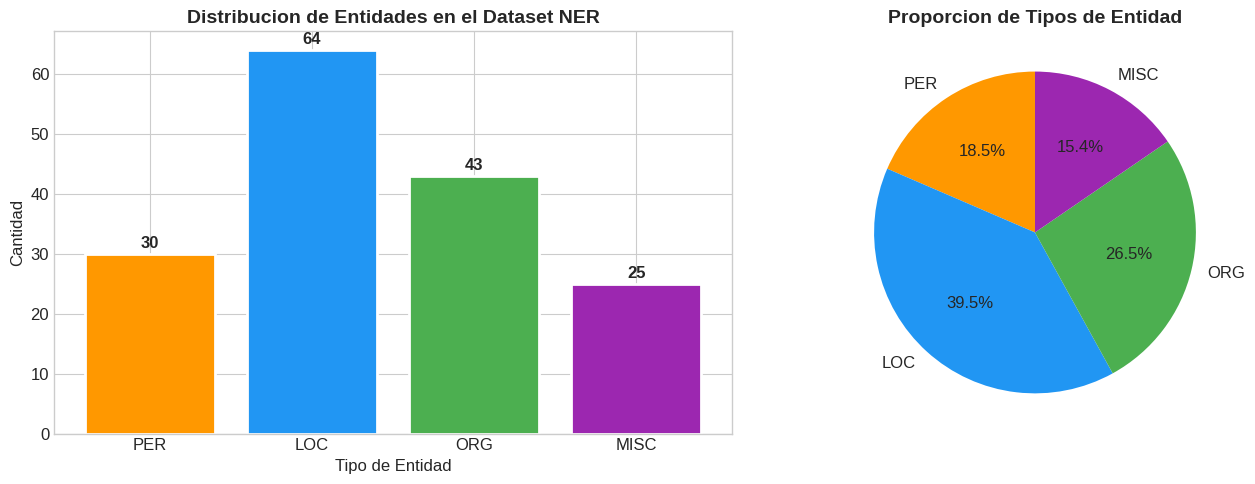


--- Ejemplos del dataset ---

Oracion 0: Gustavo Petro anuncio nuevas reformas en Bogota
  -> Gustavo Petro [PER]
  -> Bogota [LOC]

Oracion 3: Gabriel Garcia Marquez nacio en Aracataca , Colombia
  -> Gabriel Garcia Marquez [PER]
  -> Aracataca [LOC]
  -> Colombia [LOC]

Oracion 10: James Rodriguez ficho por el Rayo Vallecano
  -> James Rodriguez [PER]
  -> Rayo Vallecano [ORG]

Oracion 20: Google abrio oficinas en Bogota para toda Latinoamerica
  -> Google [ORG]
  -> Bogota [LOC]
  -> Latinoamerica [LOC]

Oracion 30: El Carnaval de Barranquilla es Patrimonio de la Humanidad
  -> Carnaval de Barranquilla [MISC]


In [38]:
# Visualizar distribucion de entidades
tipos = list(conteo_entidades.keys())
cantidades = list(conteo_entidades.values())

colores = {'LOC': '#2196F3', 'ORG': '#4CAF50', 'PER': '#FF9800', 'MISC': '#9C27B0'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras
barras = axes[0].bar(tipos, cantidades, color=[colores.get(t, '#999') for t in tipos], edgecolor='white', linewidth=2)
axes[0].set_title('Distribucion de Entidades en el Dataset NER', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Entidad')
axes[0].set_ylabel('Cantidad')
for barra, cant in zip(barras, cantidades):
    axes[0].text(barra.get_x() + barra.get_width()/2., barra.get_height() + 0.5,
                str(cant), ha='center', va='bottom', fontweight='bold', fontsize=12)

# Grafico de torta
axes[1].pie(cantidades, labels=tipos, autopct='%1.1f%%', startangle=90,
           colors=[colores.get(t, '#999') for t in tipos],
           textprops={'fontsize': 12})
axes[1].set_title('Proporcion de Tipos de Entidad', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar algunas oraciones de ejemplo
print("\n--- Ejemplos del dataset ---")
for i in [0, 3, 10, 20, 30]:
    tokens = dataset_ner[i]['tokens']
    tags = dataset_ner[i]['ner_tags']
    print(f"\nOracion {i}: {' '.join(tokens)}")
    entidades = []
    j = 0
    while j < len(tags):
        if tags[j].startswith('B-'):
            tipo = tags[j][2:]
            entidad = [tokens[j]]
            j += 1
            while j < len(tags) and tags[j].startswith('I-'):
                entidad.append(tokens[j])
                j += 1
            entidades.append((' '.join(entidad), tipo))
        else:
            j += 1
    for ent, tipo in entidades:
        print(f"  -> {ent} [{tipo}]")

---
## 4. Experimentacion Guiada

### Experimento 1: Generacion de Texto con Pipeline

Comenzamos explorando la generacion de texto usando un modelo GPT-2 en espanol a traves del pipeline de Hugging Face. El modelo recibe un "prompt" (texto inicial) y genera una continuacion coherente.

In [39]:
# Cargar el modelo de generacion de texto en espanol
# Usamos 'datificate/gpt2-small-spanish', un GPT-2 entrenado con texto en espanol
print("Cargando modelo de generacion de texto en espanol...")
print("(Esto puede tardar unos minutos la primera vez)\n")

generador = pipeline(
    'text-generation',
    model='datificate/gpt2-small-spanish',
    device=0 if torch.cuda.is_available() else -1
)

print("Modelo de generacion cargado exitosamente")

Cargando modelo de generacion de texto en espanol...
(Esto puede tardar unos minutos la primera vez)



Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo de generacion cargado exitosamente


In [40]:
# Definir 5 prompts diferentes en espanol para probar la generacion
prompts = [
    "Colombia es un pais hermoso porque",
    "La inteligencia artificial esta transformando",
    "El futbol colombiano se caracteriza por",
    "La educacion en Antioquia ha mejorado gracias a",
    "El cambio climatico afecta a las ciudades colombianas"
]

# Generar texto para cada prompt
print("=" * 80)
print("GENERACION DE TEXTO CON GPT-2 EN ESPANOL")
print("=" * 80)

resultados_exp1 = []
for i, prompt in enumerate(prompts, 1):
    # Generamos texto con parametros por defecto
    resultado = generador(
        prompt,
        max_length=100,           # Maximo 100 tokens
        num_return_sequences=1,   # Una secuencia por prompt
        do_sample=True,           # Usar sampling (no greedy)
        temperature=0.7,          # Temperature moderada
        top_p=0.9,                # Nucleus sampling
        repetition_penalty=1.2    # Penalizar repeticion
    )

    texto_generado = resultado[0]['generated_text']
    resultados_exp1.append(texto_generado)

    print(f"\n--- Prompt {i} ---")
    print(f"Prompt: \"{prompt}\"")
    print(f"Texto generado:\n{texto_generado}")
    print("-" * 60)

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GENERACION DE TEXTO CON GPT-2 EN ESPANOL


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Prompt 1 ---
Prompt: "Colombia es un pais hermoso porque"
Texto generado:
Colombia es un pais hermoso porque en el pueblo de San Miguel se celebra la fiesta patronal del Señor.
El primer domingo antes de la festividad, el 8 de agosto es tradicional que los habitantes del municipio se reúnan para realizar diferentes actividades culturales y religiosas como el concurso de música “La Virgen del Carmen”, día central desde donde se realizan diversas festividades con participación religiosa por toda la población al igual que son también las fiestas patronales y sociales por todo el estado de Nuevo León (México) hasta su propia ciudad, San Pedro Sula.
También se realiza una feria ganadera llamada "Los Carros de Los Castores", entre otros eventos además de actividades deportivas propias como fútbol sala o béisbol.
En su término, San Pedro Sula tiene 4 parroquias: El Barrio de San Pedro Sula (San Pedro Sula), La Iglesia de San Antonio de Padua, San Francisco de Asís y San Marcos de las Nie

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Prompt 2 ---
Prompt: "La inteligencia artificial esta transformando"
Texto generado:
La inteligencia artificial esta transformando en una máquina de pensamiento, que se convierte en la máquina de control y la máquina del conocimiento.

Por ejemplo:El "Icryon" fue un arma experimental desarrollada por el Instituto de Tecnología de Massachusetts para reemplazar al I-10 usado durante los años 1970s como arma contra el fuego (Signal M1). En la década siguiente, el Ejército estadounidense comenzó a desarrollar una nueva arma con una capacidad limitada de fuego más potente llamada "Motor X". El primer prototipo del AIM-9M entró en servicio en 1982 y se convirtió rápidamente en uno de sus principales blancos de defensa.

En 1988, el ejército desarrolló un prototipo de misiles guiados RIM-39 Mauser (RSM-40), conocido también como "Montaña de Combate", para reemplazar las armas del misil balístico soviético Tupolev Tu-15 VKM-12. El programa tenía cuatro objetivos principales:

Para la defe

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Prompt 3 ---
Prompt: "El futbol colombiano se caracteriza por"
Texto generado:
El futbol colombiano se caracteriza por ser un equipo de fútbol con jugadores jóvenes, y uno que ha llegado a la cima del fútbol mundial.

Los equipos más importantes en el fútbol profesional son:
Su principal rival es el Independiente Medellín; este último ya no tiene una franquicia propia desde hace muchos años, pero sí posee las rivalidades entre los grandes clubes de Colombia como el Atlético Nacional (equipo simbólico), el Atlético Bucaramanga (puerto) o el Real Madrid Castilla Club de Fútbol(jugadores). Por lo tanto, en el plano local, es el equipo más clásico para el fútbol nacional Colombiano debido al gran nivel mostrado en sus partidos disputados allí donde han marcado goles destacados como: Gabriel Besteiro, Carlos "Chavo" Vargas, Juan Pablo Duarte, Iván Duque Márquez, Andrés Iniesta, entre otros. 

Otro club importante dentro de su palmarés fue el Real Madrid Castilla, quien ganó dos Copas L

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Prompt 4 ---
Prompt: "La educacion en Antioquia ha mejorado gracias a"
Texto generado:
La educacion en Antioquia ha mejorado gracias a la labor de la Fundación para el Desarrollo Social, que apoya programas como el programa de desarrollo y el Programa de Aprendizaje Integral (PEN).
El área educativa está integrada por las siguientes escuelas:
Las Escuelas de Educación Básica - AESB - La Escuela Nacional del Profesorado Profesional, que es un proyecto nacional dirigido al mejoramiento integral de los niveles educativos primarios.
- AESB - El Programa de Formación Técnica Superior de las Empresas Públicas.
En Medellín se encuentran instituciones educativas privadas, públicas y municipales, entre ellas la Universidad EAFIT y la Universidad Pública, así mismo la Universidad Pedagógica Nacional con sede en el Centro de Estudios Superiores de Occidente (CEDEM) que promueve actividades relacionadas con educación superior tecnológica; también la Universidad Nacional de Colombia cuenta con

### ✍️ Pregunta - Experimento 1

*¿El texto generado es coherente? ¿Tiene sentido gramatical? ¿Se nota que es generado por una maquina? Justifica tu respuesta con ejemplos especificos de los textos generados.*

### ✍️ Tu respuesta:

****

¿El texto generado es coherente? ¿Tiene sentido gramatical? ¿Se nota que es generado por una maquina? Justifica tu respuesta con ejemplos especificos de los textos generados.

SENTIDO GRAMATICAL SI TIENE EL MODELO CONECTA BIEN LOS VERBOS, ARTICULOS Y SUSTANTIVOS. POR EJEMPLO EN EL PROMPT 4 ESCRIBE LA EDUCACION EN ANTIOQUIA HA MEJORADO GRACIAS A LA LABOR DE LA FUNDACION, MOSTRANDO UNA REDACCION NATURAL Y FLUIDA EN ESPAÑOL.

NO TIENE COHERENCIA EL TEXTO ESTA LLENO DE ALUCINACIONES ABSURDAS. EN EL PROMPT 1 EMPIEZA HABLANDO DE COLOMBIA Y TERMINA DICIENDO QUE LAS FIESTAS PATRONALES SON EN NUEVO LEON MEXICO HASTA SU PROPIA CIUDAD SAN PEDRO SULA HONDURAS, CONFUNDIENDO PAISES POR COMPLETO.

SI ES MUY NOTORIO QUE ES UNA MAQUINA LO DIGO POR TEMAS COMO QUE PASAN EN EL PROMPT 3 POR EJEMPLO QUE MEZCLA DATOS INCOMPATIBLES DICIENDO QUE EL EXPRESIDENTE IVAN DUQUE MARQUEZ Y ANDRES INIESTA SON HISTORICOS GOLEADORES DEL FUTBOL COLOMBIANO. ADEMAS, EN EL PROMPT 5 INVENTA MATEMATICAS IMPOSIBLES AL AFIRMAR QUE LA POBLACION URBANA TIENE 65% HOMBRES Y 49% MUJERES, LO CUAL SUMA 114% ESTA FALTA DE SENTIDO COMUN Y VERACIDAD DELATA QUE EL SISTEMA SOLO UNE PALABRAS POR PROBABILIDAD ESTADISTICA SIN ENTENDER EL MUNDO REAL Y SIN ANALIZAR TODOS LOS DATOS RELACIONADOS.

---
### Experimento 2: Efecto de la Temperature

Ahora exploraremos como el parametro `temperature` afecta la generacion de texto. Recordemos:
- **Temperature baja (0.1):** Texto mas predecible y repetitivo
- **Temperature media (0.7):** Buen equilibrio entre coherencia y creatividad
- **Temperature alta (1.5):** Texto mas creativo pero potencialmente incoherente

In [41]:
# Generar texto con el MISMO prompt pero diferentes temperatures
prompt_fijo = "La ciudad de Medellin es conocida por"
temperatures = [0.1, 0.5, 0.7, 1.0, 1.5]

print("=" * 80)
print("EFECTO DE LA TEMPERATURE EN LA GENERACION")
print(f"Prompt: \"{prompt_fijo}\"")
print("=" * 80)

resultados_temp = {}
for temp in temperatures:
    # Fijamos la semilla para que la unica variable sea la temperature
    set_seed(SEED)

    resultado = generador(
        prompt_fijo,
        max_length=80,
        num_return_sequences=1,
        do_sample=True,
        temperature=temp,
        top_p=0.95,
        repetition_penalty=1.1
    )

    texto = resultado[0]['generated_text']
    resultados_temp[temp] = texto

    print(f"\n{'='*60}")
    print(f"Temperature = {temp}")
    print(f"{'='*60}")
    print(texto)

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EFECTO DE LA TEMPERATURE EN LA GENERACION
Prompt: "La ciudad de Medellin es conocida por"


Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Temperature = 0.1
La ciudad de Medellin es conocida por su arquitectura gótica, con una gran cantidad de edificios públicos y privados.

Medellin es la sede del ayuntamiento de Medellin, que se encuentra en el centro histórico de la ciudad. El ayuntamiento está situado en el centro histórico de la ciudad, en el centro de la ciudad.

El ayuntamiento de Medellin es un edificio de estilo gótico tardío, construido entre los siglos XI y XII. El edificio fue diseñado por el arquitecto francés Jean-Baptiste Le Brun. El edificio fue terminado en el siglo XV, pero no se completó hasta el siglo XVIII.

En el siglo XIX, el ayuntamiento de Medellin fue uno de los primeros municipios en ser construidos como un municipio independiente. El ayuntamiento de Medellin fue fundado en el año de 1855, después de la fusión de Medellin y París. El ayuntamiento de Medellin fue creado en el año de 1857, después de la fusión de Medellin y París. El ayuntamiento de Medellin fue creado en el año de 1860, después 

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Temperature = 0.5
La ciudad de Medellin es conocida por su arquitectura gótica, y por sus numerosas iglesias. La iglesia de San Pedro fue construida en el siglo XI (como parte del complejo de la catedral de Weiren). La iglesia de St. Paul, construida en el siglo XII (como parte del complejo de la catedral de Weiren), fue consagrada en el siglo XIV (como parte del complejo de la catedral de Weiren) y es la única iglesia de Medellin que se encuentra fuera de la ciudad.

El castillo de Wernicke, construido entre 1142 y 1143 por los condes de Arnstein y los condes de Arnstein, fue diseñado por el conde de Arnstein, y fue construido alrededor del año 1144. El castillo de Wernicke fue nombrado en honor a Richard I de Inglaterra, duque de Kent.

En la Edad Media, el castillo de Wernicke fue utilizado como residencia real para los condes de Arnstein, y en 1185 fue convertido en la sede del condado de Arnstein, después de que el rey Enrique VIII de Inglaterra, que había sido coronado, se convi

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Temperature = 0.7
La ciudad de Medellin es conocida por su arquitectura, con muchas casas y plazas en el centro del condado.

Medellin está dividida administrativamente en cuatro distritos, Medellin Park (el distrito 1), Medellin Park (el distrito 2) y Medellin Park (el distrito 3).

El distrito 1 fue creado en el año 2000 como parte del plan municipal de los condados de Newark y Newning por el alcalde de Medellin, Mike Bland. El distrito 2 fue creado en el año 2006 por el alcalde de la ciudad, Chris Carman. El distrito 3 fue creado a partir del alcalde de Medellin, Phil Sperry.

Las antiguas murallas de Medellin se han restaurado para permitir que el tráfico rodado pueda seguir siendo posible. La mayoría de las puertas de las principales calles están ahora abiertas al público.

Medellin Park está abierto diariamente desde el año 2009 hasta el fin del año 2012; la mayor parte de las calles son de interés cultural. El Centro de Arte de Medellin está conectado con la Universidad Medelli

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Temperature = 1.0
La ciudad de Medellin es conocida por albergar el Museo Nacional de Historia Natural, ubicado en Medellin.
Medellin es una parada del Metro de Londres que comunica la mayoría de las principales rutas del país y se caracteriza por ser un lugar estratégico para los residentes de la Ciudad de Londres con vistas a las colonias británicas desde la cercana ciudad portuaria de Westminster. Hay importantes museos, así como otras empresas de renombre internacional. El servicio es accesible a través de autobuses públicos y bicicletas. 

Las líneas A, B y C conectan Medellin con Barcelona por la costa, mientras que la línea D llega a la capital por la región Oeste antes de llegar a Beacon Tower al sur de la ciudad. En las últimas décadas, la ciudad ha sido objeto de muchos planes urbanísticos de grandes complejos rascacielos. La mayoría está destinada a la vivienda pública: "Heide House" (1980), "Beacon Tower" (1986) y el nuevo New World Tower (1992).
Medellin también es el cen

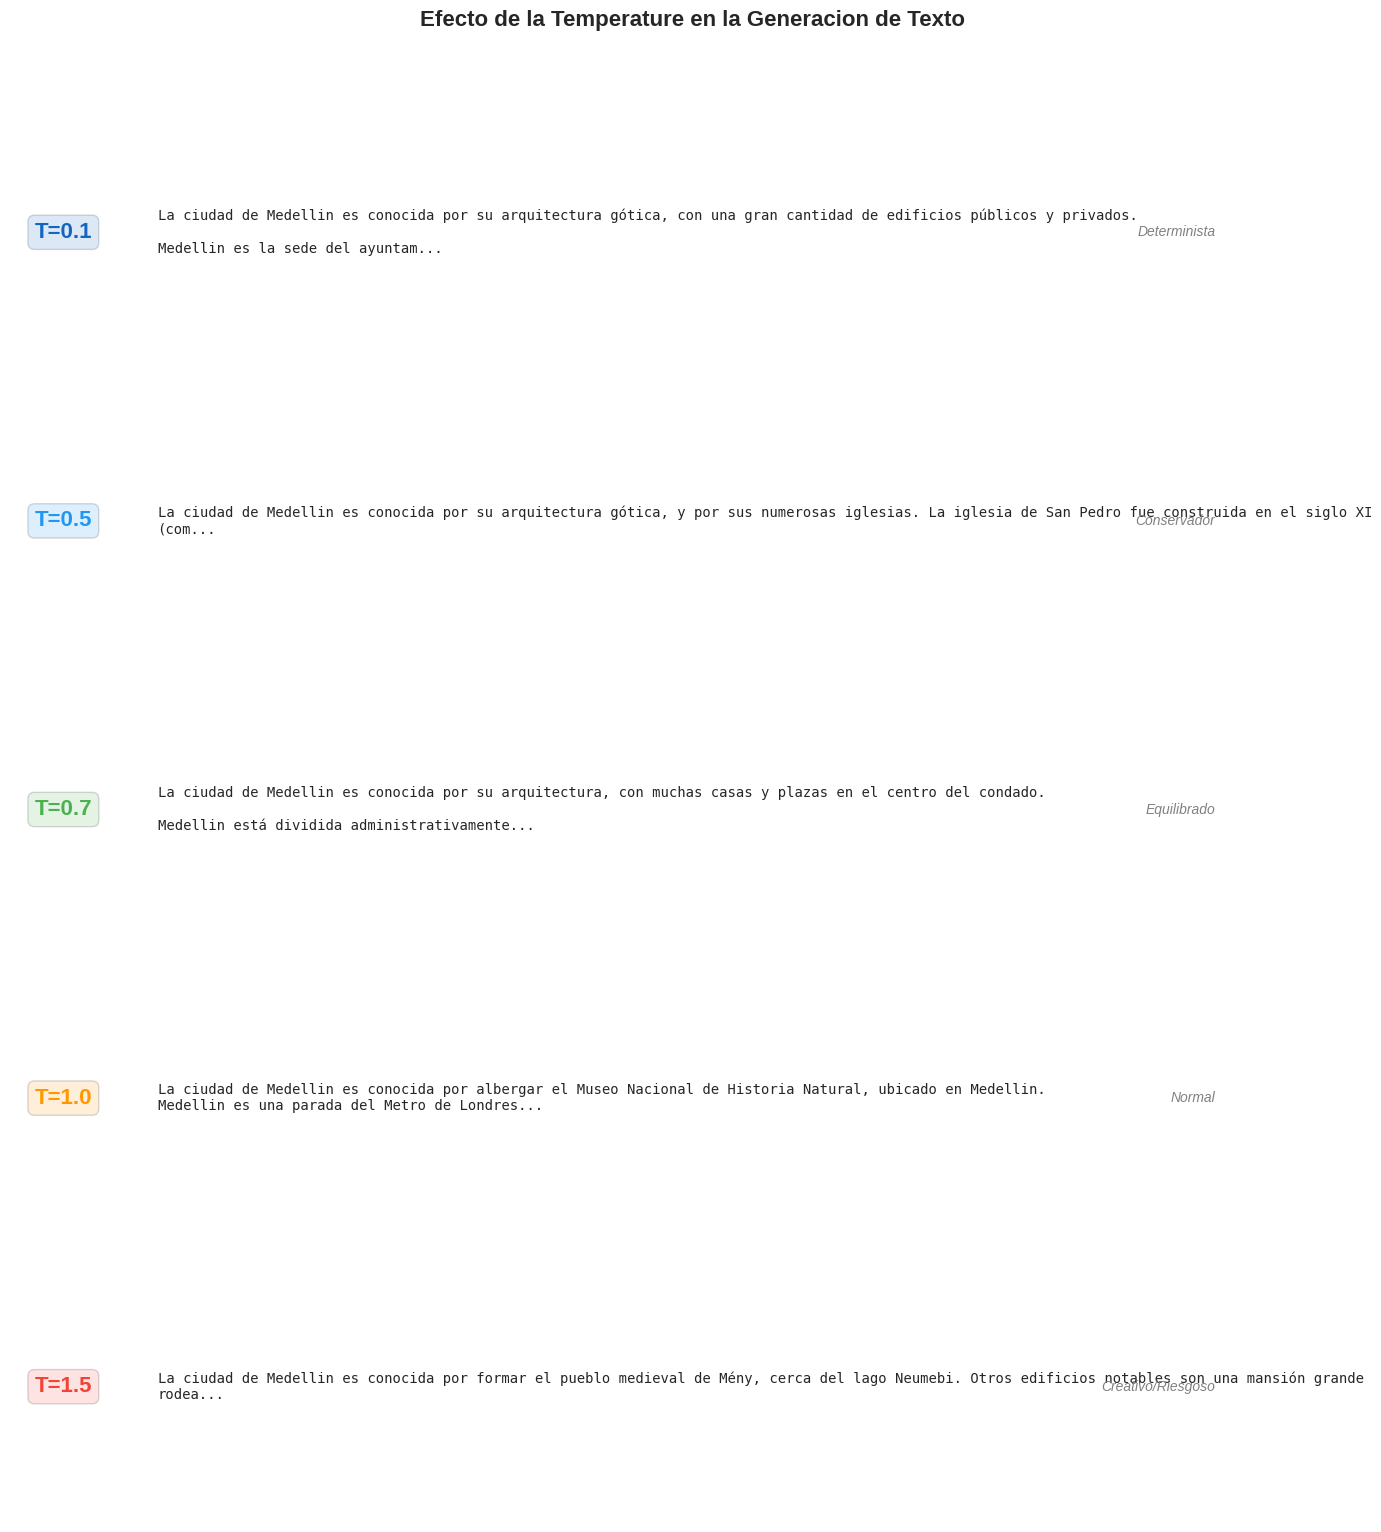

In [42]:
# Visualizacion comparativa de las temperatures
fig, axes = plt.subplots(len(temperatures), 1, figsize=(14, 3 * len(temperatures)))

colores_temp = ['#1565C0', '#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, (temp, texto) in enumerate(resultados_temp.items()):
    ax = axes[i]
    ax.text(0.02, 0.5, f"T={temp}", transform=ax.transAxes, fontsize=16,
            fontweight='bold', va='center', color=colores_temp[i],
            bbox=dict(boxstyle='round,pad=0.3', facecolor=colores_temp[i], alpha=0.15))

    # Mostrar texto truncado para visualizacion
    texto_display = texto[:150] + "..." if len(texto) > 150 else texto
    ax.text(0.12, 0.5, texto_display, transform=ax.transAxes, fontsize=10,
            va='center', wrap=True, family='monospace')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Etiqueta descriptiva
    if temp <= 0.3:
        desc = "Determinista"
    elif temp <= 0.6:
        desc = "Conservador"
    elif temp <= 0.8:
        desc = "Equilibrado"
    elif temp <= 1.1:
        desc = "Normal"
    else:
        desc = "Creativo/Riesgoso"

    ax.text(0.98, 0.5, desc, transform=ax.transAxes, fontsize=10,
            va='center', ha='right', style='italic', color='gray')

fig.suptitle('Efecto de la Temperature en la Generacion de Texto',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ✍️ Pregunta - Experimento 2

*¿Como cambia el texto con diferentes temperatures? ¿Cual te parece mas natural? ¿Cual es mas creativo? Identifica diferencias concretas entre las generaciones.*

### ✍️ Tu respuesta:

****

Como cambia el texto con diferentes temperatures? ¿Cual te parece mas natural? ¿Cual es mas creativo? Identifica diferencias concretas entre las generaciones.

COMO CAMBIA EL TEXTO: A MEDIDA QUE AUMENTA LA TEMPERATURA, EL MODELO PASA DE SER UN SISTEMA RIGIDO Y REPETITIVO A SER UN SISTEMA COMPLETAMENTE ALOCADO Y DE CAOS TOTAL EXPANDIENDO LA VARIEDAD DE PALABRAS QUE SE ATREVE A USAR.

CUAL ES MAS NATURAL: LA DE TEMPERATURE = 0.7 EQUILIBRADO. MANTIENE UNA REDACCION CON BUEN SENTIDO COMUN SIN CAER EN BUCLES REPETITIVOS NI EN GENERAR PALABRAS INVENTADAS, LOGRANDO UNA ESTRUCTURA DE TEXTO MUY SIMILAR A LA HUMANA.

CUAL ES MAS CREATIVO: LA DE TEMPERATURE = 1.5 CREATIVO Y RIESGOSO. EL MODELO SE ARRIESGA TANTO QUE CREA NUEVAS ESTRUCTURAS GRAMATICALES Y MODIFICA PROPIOS NOMBRE REALES DE FORMA DISRUPTIVA.

DIFERENCIAS CONCRETAS IDENTIFICADAS:

CON T=0.1 DETERMINISTA: SE PRODUCE EL EFECTO DE BUCLE INFINITO. EL MODELO ESCRIBE CUATRO VECES SEGUIDAS CASI LA MISMA LINEA: EL AYUNTAMIENTO DE MEDELLIN FUE CREADO EN EL AÑO DE DESPUES DE LA FUSION DE MEDELLIN Y PARIS.

CON T=0.7 EQUILIBRADO: PROPONE UNA REDACCION COHERENTE INVENTANDO UN PLAN MUNICIPAL CON DISTRITOS FICTICIOS LLAMADOS MEDELLIN PARK DEL 1 AL 3.

CON T=1.0 NORMAL: LA LOGICA FACTUAL SE DESTRUYE POR COMPLETO AL AFIRMAR QUE MEDELLIN ES UNA ESTACION COMPLETA DEL METRO DE LONDRES CERCA DE WESTMINSTER.

CON T=1.5 CAOTICO: LA CREATIVIDAD SE SALE DE CONTROL Y EL MODELO EMPIEZA A DEFORMAR EL IDIOMA E INVENTAR PALABRAS DERIVADAS QUE NO EXISTEN COMO MEDELLINAS, MEDELLINAE, MEDELLINI Y MEDELLINOS, ADEMAS DE MEZCLAR PERSONAJES COMO LOS EMPERADORES VESPASIANO EN UNA MISMA FRASE.

---
### Experimento 3: Top-k y Top-p Sampling

Exploramos ahora dos mecanismos de filtrado de tokens: top-k (elegir entre los k mas probables) y top-p (elegir tokens cuya probabilidad acumulada no supere p).

In [43]:
# Experimento con Top-k: variando el numero de tokens candidatos
prompt_fijo = "En el futuro, la inteligencia artificial"
valores_top_k = [10, 50, 100]

print("=" * 80)
print("EFECTO DE TOP-K SAMPLING")
print(f"Prompt: \"{prompt_fijo}\"")
print("=" * 80)

resultados_topk = {}
for k in valores_top_k:
    set_seed(SEED)
    resultado = generador(
        prompt_fijo,
        max_length=80,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.8,
        top_k=k,
        repetition_penalty=1.1
    )
    texto = resultado[0]['generated_text']
    resultados_topk[k] = texto

    print(f"\n--- top_k = {k} ---")
    print(texto)
    print()

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EFECTO DE TOP-K SAMPLING
Prompt: "En el futuro, la inteligencia artificial"


Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- top_k = 10 ---
En el futuro, la inteligencia artificial podría ser un elemento de gran importancia en los sistemas digitales, como las computadoras. En la década de 1970, el término inteligencia artificial apareció por primera vez y se utilizó para designar a una clase de inteligencia artificial que podría realizar tareas de procesamiento de datos con la ayuda del procesamiento de información mediante inteligencia artificial. La inteligencia artificial fue utilizada principalmente por el Departamento de Defensa (DDO) como un método para mejorar métodos de análisis de información sobre la base de la información. El concepto fue aplicado al desarrollo de inteligencia artificial de gran escala desde la década de 1950 hasta principios de la década de 1980 y fue utilizado también durante décadas después.

El concepto de inteligencia artificial es ampliamente aceptado, pero no está claro cuál es realmente su verdadera naturaleza, si se refiere a la capacidad de un humano o una máquina p

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- top_k = 50 ---
En el futuro, la inteligencia artificial podría ser tan grande que pueda hacer cualquier cosa para él.

La inteligencia artificial no puede construir una nave espacial sin desarrollar una gran cantidad de naves espaciales y desarrollar máquinas superpuestas sin ningún coste significativo por su construcción, como es el caso con la construcción de naves espaciales. Por ello, aunque la mayoría de las naves espaciales no poseen un sistema de defensa (es decir, sistemas de defensa "increíble"), la nave espacial sigue siendo bastante importante en su economía.

El principal problema de la ingeniería de la nave espacial es que, a pesar del gran gasto realizado en su construcción, no existe ninguna ciencia capaz de hacer frente al costo de su trabajo hasta después de finalizada la construcción. Esto se debe al pequeño número de recursos disponibles para la construcción que no poseen los recursos necesarios para construir la nave espacial: la cantidad de recursos de la fábr

In [44]:
# Experimento con Top-p: variando el umbral de probabilidad acumulada
valores_top_p = [0.5, 0.8, 0.95]

print("=" * 80)
print("EFECTO DE TOP-P (NUCLEUS) SAMPLING")
print(f"Prompt: \"{prompt_fijo}\"")
print("=" * 80)

resultados_topp = {}
for p in valores_top_p:
    set_seed(SEED)
    resultado = generador(
        prompt_fijo,
        max_length=80,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.8,
        top_p=p,
        repetition_penalty=1.1
    )
    texto = resultado[0]['generated_text']
    resultados_topp[p] = texto

    print(f"\n--- top_p = {p} ---")
    print(texto)
    print()

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EFECTO DE TOP-P (NUCLEUS) SAMPLING
Prompt: "En el futuro, la inteligencia artificial"


Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- top_p = 0.5 ---
En el futuro, la inteligencia artificial podría ser utilizada para hacer más rápido y más eficaz las misiones de espionaje. El proyecto fue desarrollado por primera vez en el año 2005 por la Universidad de California en Berkeley.

El programa es un conjunto de dos partes:


La primera parte de la inteligencia artificial se basa en la inteligencia artificial de la inteligencia artificial de la inteligencia artificial. La inteligencia artificial se basa en la inteligencia artificial de la inteligencia artificial de la inteligencia artificial del usuario. El usuario puede crear una aplicación que sea similar a la inteligencia artificial de la inteligencia artificial, pero con la misma capacidad de crear aplicaciones de inteligencia artificial. La inteligencia artificial de la inteligencia artificial se basa en la inteligencia artificial de la inteligencia artificial de la inteligencia artificial de la inteligencia artificial de la inteligencia artificial de la intelig

Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- top_p = 0.8 ---
En el futuro, la inteligencia artificial podría ser un elemento clave en la trama de la película, y las fuerzas de seguridad que operan en el mundo real podrían ser responsables del ataque.

"Gunster" recibió críticas mixtas a positivas por parte de los críticos, quienes elogiaron la actuación de James Spahn como el personaje principal de la serie. También fueron favorables sus actuaciones en la primera temporada, con un puntaje promedio de "B" en una escala de A + a F. El sitio web Rotten Tomatoes le dio al episodio una calificación de aprobación del 67% basado en más de 2.621 votos, lo cual indica "críticas generalmente favorables". El consenso crítico dice: "El episodio es bueno para todos, pero la actuación es un poco repetitiva, demasiado torpemente cargada de tensión y momentos de clichés son casi imposibles de entender." En su revisión de la película, David Jeffries escribió que "con los personajes principales (Karen, Luke y John) se hace menos interesante q

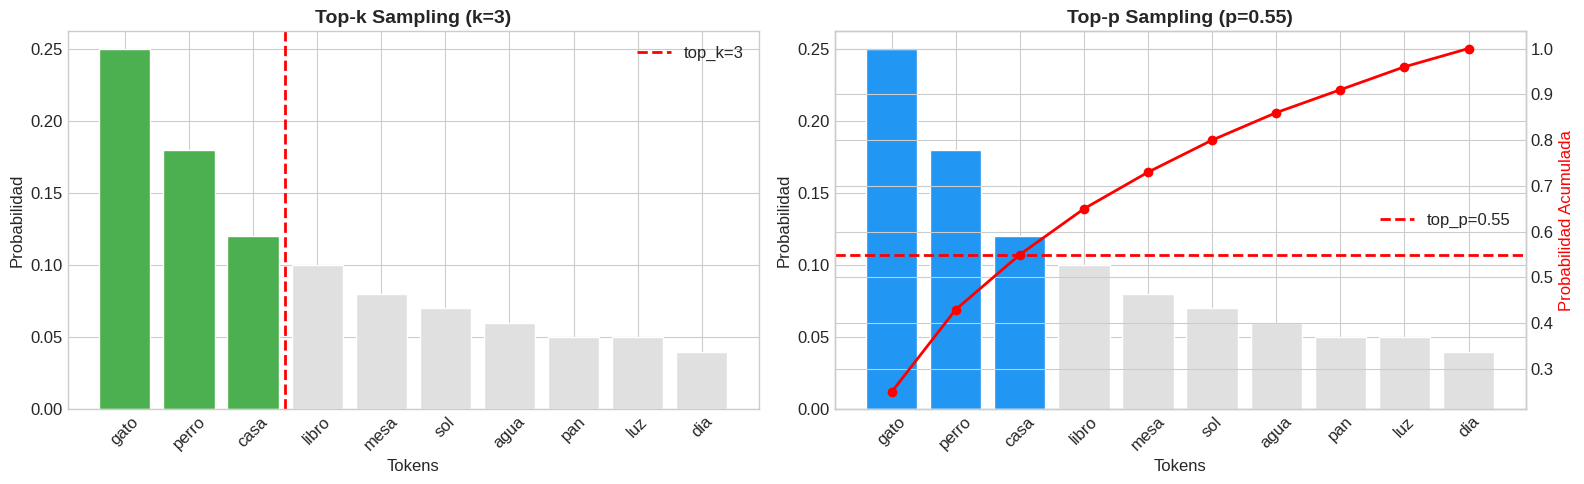


Verde/Azul = tokens seleccionados | Gris = tokens descartados
Top-k: selecciona un numero fijo de tokens
Top-p: selecciona tokens hasta alcanzar una probabilidad acumulada


In [45]:
# Comparacion visual de top_k vs top_p
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Esquema conceptual de top-k
tokens_ejemplo = ['gato', 'perro', 'casa', 'libro', 'mesa', 'sol', 'agua', 'pan', 'luz', 'dia']
probs_ejemplo = [0.25, 0.18, 0.12, 0.10, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04]

colores_k = ['#4CAF50' if i < 3 else '#E0E0E0' for i in range(len(tokens_ejemplo))]
barras1 = ax1.bar(tokens_ejemplo, probs_ejemplo, color=colores_k, edgecolor='white')
ax1.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='top_k=3')
ax1.set_title('Top-k Sampling (k=3)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tokens')
ax1.set_ylabel('Probabilidad')
ax1.legend(fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Esquema conceptual de top-p
prob_acumulada = np.cumsum(probs_ejemplo)
colores_p = ['#2196F3' if prob_acumulada[i] <= 0.55 else '#E0E0E0' for i in range(len(tokens_ejemplo))]
barras2 = ax2.bar(tokens_ejemplo, probs_ejemplo, color=colores_p, edgecolor='white')
# Linea de probabilidad acumulada
ax2_twin = ax2.twinx()
ax2_twin.plot(tokens_ejemplo, prob_acumulada, 'ro-', linewidth=2, markersize=6)
ax2_twin.axhline(y=0.55, color='red', linestyle='--', linewidth=2, label='top_p=0.55')
ax2_twin.set_ylabel('Probabilidad Acumulada', color='red')
ax2_twin.legend(fontsize=12, loc='center right')
ax2.set_title('Top-p Sampling (p=0.55)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tokens')
ax2.set_ylabel('Probabilidad')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nVerde/Azul = tokens seleccionados | Gris = tokens descartados")
print("Top-k: selecciona un numero fijo de tokens")
print("Top-p: selecciona tokens hasta alcanzar una probabilidad acumulada")

### ✍️ Pregunta - Experimento 3

*¿Cual combinacion de top_k y top_p produce texto mas natural? ¿Hay diferencia entre controlar con temperature vs top_k? ¿Cual mecanismo prefieres y por que?*

### ✍️ Tu respuesta:
****
¿Cual combinacion de top_k y top_p produce texto mas natural? ¿Hay diferencia entre controlar con temperature vs top_k? ¿Cual mecanismo prefieres y por que?

LA COMBINACION MAS NATURAL SE LOGRA CON TOP_K = 50, TOP-P = 0.85 Y TEMPERATURE = 0.7, YA QUE EQUILIBRA LA FLUIDEZ SIN CAER EN BUCLES REPETITIVOS NI EN ALUCINACIONES RARAS DE NAVES ESPACIALES. LA DIFERENCIA RADICAL ES QUE LA TEMPERATURE RECONFIGURA LA CURVA DE PROBABILIDAD DE LOS TOKENS PARA DARLES MAS O MENOS FUERZA, MIENTRAS QUE EL TOP_K ES UN CORTE DE TIJERA RIGIDO QUE ELIMINA LAS OPCIONES MENOS PROBABLES SIN ALTERAR SUS VALORES. POR ESTO SE PREFIERE EL MECANISMO TOP-P, YA QUE SU FILTRADO ES DINAMICO: SI EL MODELO TIENE CERTEZA SE CIERRA A POCAS PALABRAS PARA EVITAR ERRORES, PERO SI TIENE DUDAS ABRE EL ABANICO AUTOMATICAMENTE PERMITIENDO UNA VARIABILIDAD MUCHO MÁS CREATIVA Y ORGANICA SEGUN EL CONTEXTO.

---
### Experimento 4: Generacion Controlada y Repetition Penalty

Cuando generamos texto largo, los modelos tienden a repetir frases. El parametro `repetition_penalty` penaliza los tokens que ya aparecieron, reduciendo este problema.

In [46]:
# Generar texto LARGO sin repetition_penalty
prompt_largo = "La historia de Colombia comienza"

print("=" * 80)
print("GENERACION LARGA SIN REPETITION PENALTY")
print("=" * 80)

set_seed(SEED)
resultado_sin_penalty = generador(
    prompt_largo,
    max_length=250,
    num_return_sequences=1,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    repetition_penalty=1.0  # Sin penalizacion (valor por defecto)
)

texto_sin_penalty = resultado_sin_penalty[0]['generated_text']
print("\nSIN repetition_penalty (1.0):")
print("-" * 40)
print(texto_sin_penalty)

Both `max_new_tokens` (=256) and `max_length`(=250) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GENERACION LARGA SIN REPETITION PENALTY

SIN repetition_penalty (1.0):
----------------------------------------
La historia de Colombia comienza en el año 1952, cuando se creó la Sociedad Colombiana de Fútbol Profesional (COFAP) y en el año 1958 se creó la Federación Colombiana de Fútbol Profesional (FPCF) (Fútbol Colombiano).

La primera edición de la Copa Colombia de 1958 fue disputada en Colombia, donde fue la primera vez que se jugó un torneo internacional.

En el año 1961 se realizaron los primeros partidos oficiales de la Copa Colombia y en 1962 se realizó el primer torneo oficial de la Copa Colombia de 1963.

La Federación Colombiana de Fútbol Profesional (FPCF) fue creada por la Asamblea General de la FIFA el 7 de febrero de 1962. La primera sede de la Federación Colombiana de Fútbol (FPCF) se encuentra en Bogotá, en la ciudad de Bogotá.

El 5 de febrero de 1964 la Federación Colombiana de Fútbol Profesional (FPCF) celebró su primer torneo oficial en el país, siendo la primera 

In [47]:
# Generar texto LARGO con diferentes valores de repetition_penalty
valores_penalty = [1.0, 1.2, 1.5, 2.0]

print("=" * 80)
print("COMPARACION DE REPETITION PENALTY")
print(f"Prompt: \"{prompt_largo}\"")
print("=" * 80)

resultados_penalty = {}
for penalty in valores_penalty:
    set_seed(SEED)
    resultado = generador(
        prompt_largo,
        max_length=200,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        repetition_penalty=penalty
    )
    texto = resultado[0]['generated_text']
    resultados_penalty[penalty] = texto

    print(f"\n{'='*60}")
    print(f"repetition_penalty = {penalty}")
    print(f"{'='*60}")
    print(texto[:300])
    print()

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


COMPARACION DE REPETITION PENALTY
Prompt: "La historia de Colombia comienza"


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



repetition_penalty = 1.0
La historia de Colombia comienza en el año 1952, cuando se creó la Sociedad Colombiana de Fútbol Profesional (COFAP) y en el año 1958 se creó la Federación Colombiana de Fútbol Profesional (FPCF) (Fútbol Colombiano).

La primera edición de la Copa Colombia de 1958 fue disputada en Colombia, donde fu



Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



repetition_penalty = 1.2
La historia de Colombia comienza en el año 1952, cuando se creó la Sociedad Colombiana del Fútbol Profesional (COFAP). La primera liga profesional fue la Copa Libertadores 1953.
En 1958 fue creada la Asociación Colombiano de Fútbol y más tarde fue transformada en la Federación Colombiana de Fútbol. 



Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



repetition_penalty = 1.5
La historia de Colombia comienza en el año 1952, cuando se creó la Sociedad Colombiana del Fútbol Profesional (COFAP). La primera liga profesional fue la Copa Libertadores 1953.
En 1958 fue creada la Asociación Colombiano para la formación y desarrollo dentro eclesiales por parte colombiana con sede


repetition_penalty = 2.0
La historia de Colombia comienza en el año 1952, cuando se creó la Sociedad Colombiana del Fútbol Profesional (COFAP). La primera liga profesional fue la Copa Libertadores 1953.
En 1958 fue creada la Asociación Colombiano para la formación y desarrollo dentro eclesiales por parte colombiana con sede




ANALISIS DE REPETICION (trigramas repetidos)
Penalty=1.0: 15/207 trigramas repetidos (7.2%)
Penalty=1.2: 1/231 trigramas repetidos (0.4%)
Penalty=1.5: 0/234 trigramas repetidos (0.0%)
Penalty=2.0: 0/230 trigramas repetidos (0.0%)


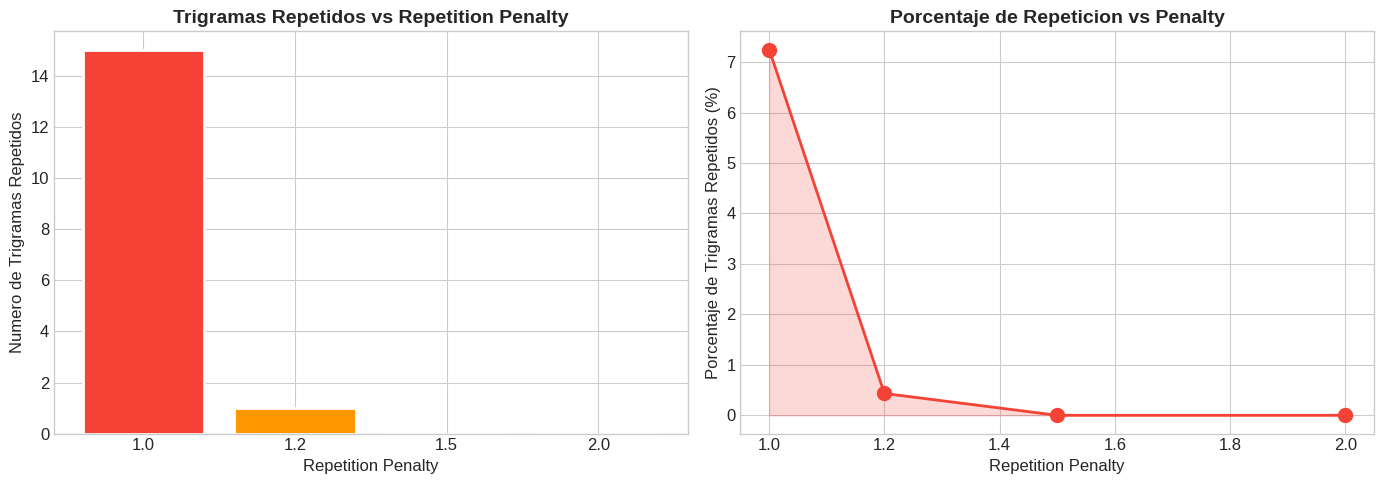

In [48]:
# Analisis de repeticion: contar n-gramas repetidos en cada generacion
def contar_ngramas_repetidos(texto, n=3):
    """Cuenta cuantos n-gramas se repiten en el texto."""
    palabras = texto.lower().split()
    ngramas = [' '.join(palabras[i:i+n]) for i in range(len(palabras) - n + 1)]
    conteo = Counter(ngramas)
    repetidos = sum(1 for v in conteo.values() if v > 1)
    total = len(ngramas)
    return repetidos, total

print("\n" + "=" * 60)
print("ANALISIS DE REPETICION (trigramas repetidos)")
print("=" * 60)

penalties = []
repetidos_lista = []
porcentajes = []

for penalty, texto in resultados_penalty.items():
    repetidos, total = contar_ngramas_repetidos(texto)
    porcentaje = (repetidos / total * 100) if total > 0 else 0
    penalties.append(penalty)
    repetidos_lista.append(repetidos)
    porcentajes.append(porcentaje)
    print(f"Penalty={penalty}: {repetidos}/{total} trigramas repetidos ({porcentaje:.1f}%)")

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar([str(p) for p in penalties], repetidos_lista, color=['#F44336', '#FF9800', '#4CAF50', '#2196F3'],
       edgecolor='white', linewidth=2)
ax1.set_title('Trigramas Repetidos vs Repetition Penalty', fontsize=14, fontweight='bold')
ax1.set_xlabel('Repetition Penalty')
ax1.set_ylabel('Numero de Trigramas Repetidos')

ax2.plot(penalties, porcentajes, 'o-', color='#F44336', linewidth=2, markersize=10)
ax2.fill_between(penalties, porcentajes, alpha=0.2, color='#F44336')
ax2.set_title('Porcentaje de Repeticion vs Penalty', fontsize=14, fontweight='bold')
ax2.set_xlabel('Repetition Penalty')
ax2.set_ylabel('Porcentaje de Trigramas Repetidos (%)')

plt.tight_layout()
plt.show()

### ✍️ Pregunta - Experimento 4

*¿Cuanto repetition_penalty es optimo? ¿Que pasa si es demasiado alto (ej: 2.0)? ¿El texto pierde coherencia con penalties altos? Justifica con los resultados observados.*

### ✍️ Tu respuesta:

****
EL VALOR OPTIMO ES 1.2 PORQUE BAJA LA REPETICION DEL 7.2% AL 0.4% EN LOS GRAFICOS SIN DAÑAR LA REDACCION DEL TEXTO. SI SE REVISA EL CASO DE 2.0, EL TEXTO SE ROMPE POR COMPLETO Y TERMINA EN FRASES SIN SENTIDO COMO DESARROLLO DENTRO ECLESIALES POR PARTE COLOMBIANA CON SEDE. ESTO PASA PORQUE EL MODELO SUFRE UNA CENSURA TAN AGRESIVA QUE LE PROHIBE REPETIR INCLUSO CONECTORES BASICOS COMO EL, LA O DE, OBLIGANDOLO A METER CUALQUIER PALABRA RARA CON TAL DE MARCAR EL 0.0% DE REPETICION QUE MUESTRA LA GRAFICA.

---
### Experimento 5: NER con Pipeline de Hugging Face

Ahora pasamos al **Reconocimiento de Entidades Nombradas (NER)**. Usaremos un modelo BERT en espanol ajustado para NER que puede detectar personas, organizaciones, ubicaciones y otras entidades en texto.

In [49]:
# Cargar el modelo de NER en espanol
# Usamos un modelo BERT espanol fine-tuned para NER
print("Cargando modelo de NER en espanol...")
print("(Esto puede tardar unos minutos la primera vez)\n")

modelo_ner = pipeline(
    'ner',
    model='mrm8488/bert-spanish-cased-finetuned-ner',
    tokenizer='mrm8488/bert-spanish-cased-finetuned-ner',
    aggregation_strategy='simple',  # Agrupa sub-tokens en entidades completas
    device=0 if torch.cuda.is_available() else -1
)

print("Modelo NER cargado exitosamente")

Cargando modelo de NER en espanol...
(Esto puede tardar unos minutos la primera vez)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: mrm8488/bert-spanish-cased-finetuned-ner
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo NER cargado exitosamente


In [50]:
# Probar NER con 10 oraciones en espanol con entidades variadas
oraciones_prueba = [
    "Gabriel Garcia Marquez escribio Cien anos de soledad en Cartagena.",
    "Shakira nacio en Barranquilla y ahora vive en Miami.",
    "Ecopetrol es la empresa mas grande de Colombia con sede en Bogota.",
    "James Rodriguez jugo en el Real Madrid y el Bayern Munich.",
    "La Universidad de Antioquia fue fundada en Medellin en 1803.",
    "El presidente Gustavo Petro visito Cali para inaugurar un hospital.",
    "Google y Microsoft abrieron oficinas en Bogota para America Latina.",
    "Egan Bernal gano el Tour de Francia en 2019 representando a Colombia.",
    "El Banco de la Republica fijo la tasa de interes en 13 por ciento.",
    "Juanes y Carlos Vives cantaron juntos en el Festival Vallenato de Valledupar."
]

print("=" * 80)
print("RECONOCIMIENTO DE ENTIDADES NOMBRADAS (NER)")
print("=" * 80)

resultados_ner = {}
for i, oracion in enumerate(oraciones_prueba, 1):
    entidades = modelo_ner(oracion)
    resultados_ner[oracion] = entidades

    print(f"\n--- Oracion {i} ---")
    print(f"Texto: {oracion}")
    print(f"Entidades encontradas:")

    if entidades:
        for ent in entidades:
            # Limpiar nombre de entidad (quitar ## de sub-tokens)
            nombre = ent['word'].replace('##', '')
            tipo = ent['entity_group']
            confianza = ent['score']
            print(f"  -> \"{nombre}\" | Tipo: {tipo} | Confianza: {confianza:.4f}")
    else:
        print("  (No se detectaron entidades)")
    print()

RECONOCIMIENTO DE ENTIDADES NOMBRADAS (NER)

--- Oracion 1 ---
Texto: Gabriel Garcia Marquez escribio Cien anos de soledad en Cartagena.
Entidades encontradas:
  -> "Gabriel Garcia Marquez" | Tipo: PER | Confianza: 0.9994
  -> "Cien anos de soledad" | Tipo: MISC | Confianza: 0.9995
  -> "Cartagena" | Tipo: LOC | Confianza: 0.9980


--- Oracion 2 ---
Texto: Shakira nacio en Barranquilla y ahora vive en Miami.
Entidades encontradas:
  -> "Shakira" | Tipo: PER | Confianza: 0.9993
  -> "Barranquilla" | Tipo: LOC | Confianza: 0.9982
  -> "Miami" | Tipo: LOC | Confianza: 0.9999


--- Oracion 3 ---
Texto: Ecopetrol es la empresa mas grande de Colombia con sede en Bogota.
Entidades encontradas:
  -> "Ecopetrol" | Tipo: ORG | Confianza: 0.9898
  -> "Colombia" | Tipo: LOC | Confianza: 0.9994
  -> "Bogota" | Tipo: LOC | Confianza: 0.8769


--- Oracion 4 ---
Texto: James Rodriguez jugo en el Real Madrid y el Bayern Munich.
Entidades encontradas:
  -> "James Rodriguez" | Tipo: PER | Confianza: 0.99

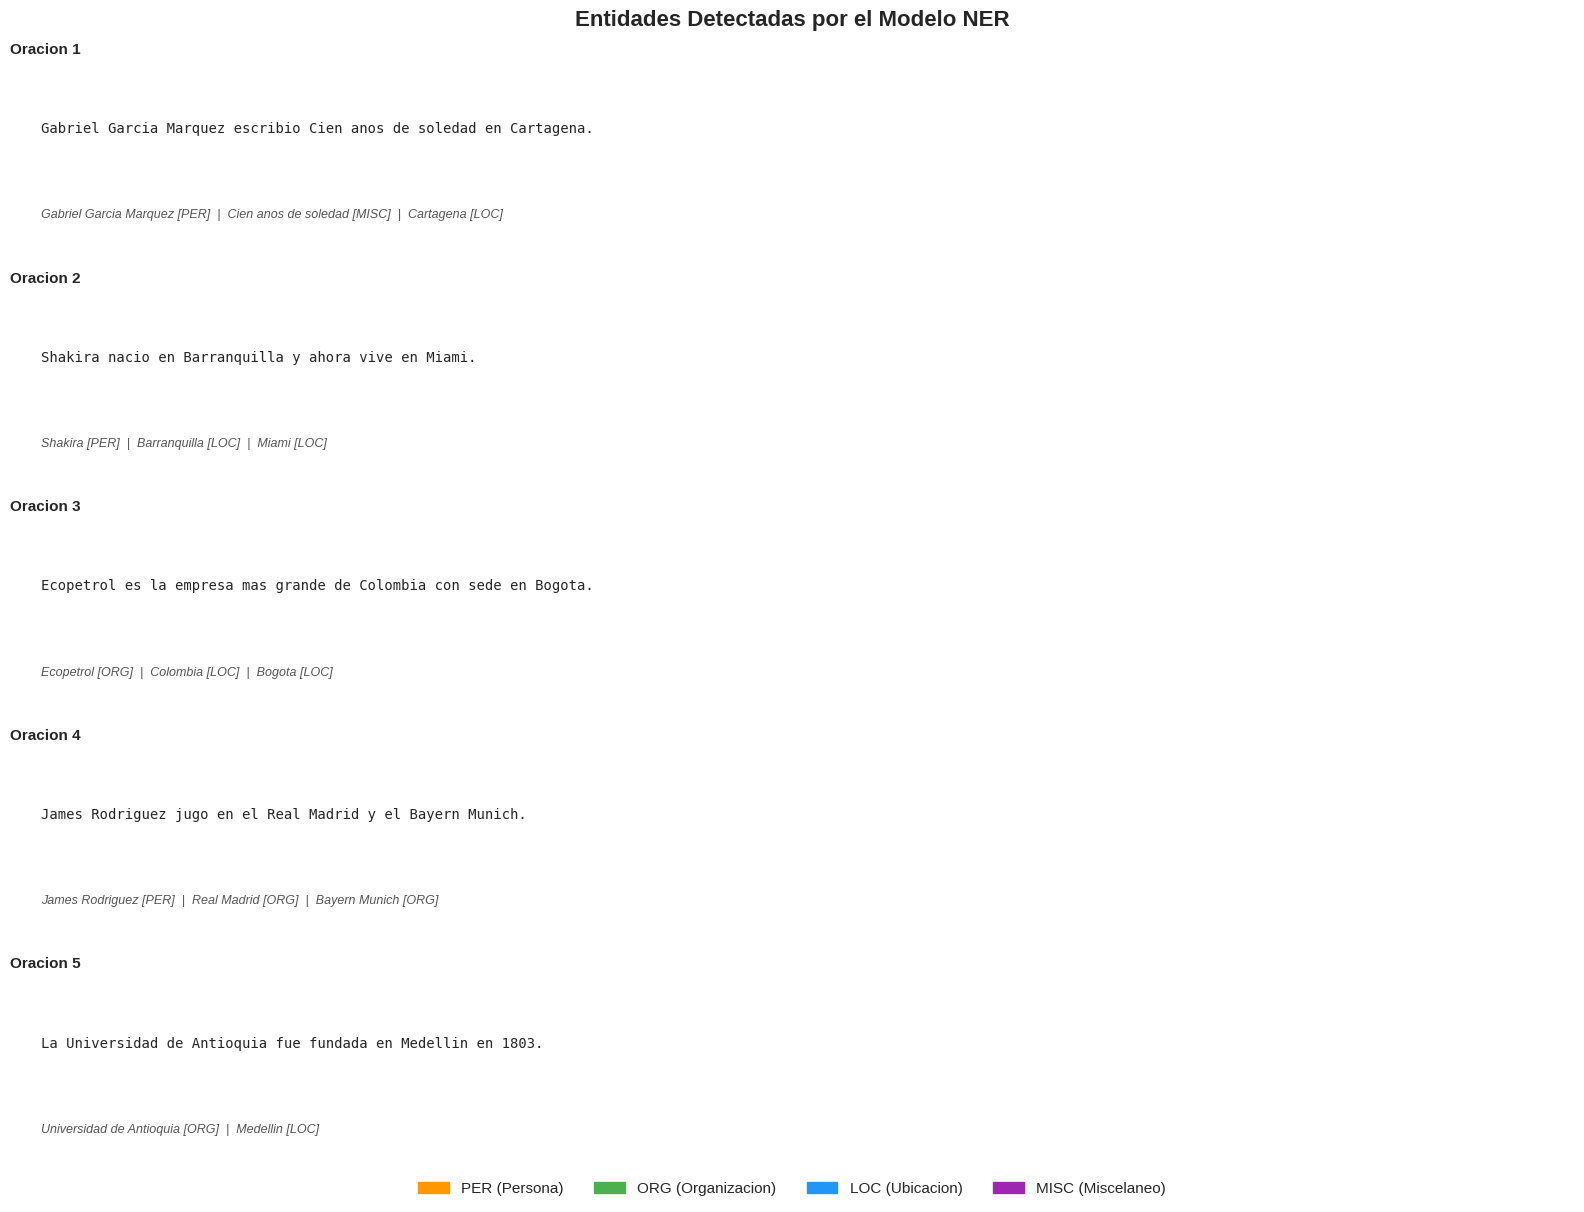

In [51]:
# Funcion para visualizar entidades resaltadas en el texto
def visualizar_entidades(texto, entidades, ax=None, titulo=None):
    """Visualiza un texto con sus entidades resaltadas usando colores."""
    colores_ent = {
        'PER': '#FF9800',   # Naranja para personas
        'ORG': '#4CAF50',   # Verde para organizaciones
        'LOC': '#2196F3',   # Azul para ubicaciones
        'MISC': '#9C27B0',  # Morado para miscelaneo
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 2))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    if titulo:
        ax.set_title(titulo, fontsize=11, fontweight='bold', loc='left')

    # Construir texto con anotaciones
    texto_anotado = texto
    entidades_info = []
    for ent in sorted(entidades, key=lambda x: x['start']):
        nombre = texto[ent['start']:ent['end']]
        tipo = ent['entity_group']
        entidades_info.append(f"{nombre} [{tipo}]")

    # Mostrar texto y entidades debajo
    ax.text(0.02, 0.65, texto, fontsize=10, va='center', wrap=True,
           family='monospace', transform=ax.transAxes)

    if entidades_info:
        resumen = "  |  ".join(entidades_info)
        ax.text(0.02, 0.2, resumen, fontsize=9, va='center',
               color='#555', style='italic', transform=ax.transAxes)

    return ax


# Visualizar las primeras 5 oraciones con sus entidades
fig, axes = plt.subplots(5, 1, figsize=(16, 12))

for i, oracion in enumerate(oraciones_prueba[:5]):
    entidades = resultados_ner[oracion]
    visualizar_entidades(oracion, entidades, ax=axes[i],
                        titulo=f"Oracion {i+1}")

# Leyenda de colores
leyenda_patches = [
    mpatches.Patch(color='#FF9800', label='PER (Persona)'),
    mpatches.Patch(color='#4CAF50', label='ORG (Organizacion)'),
    mpatches.Patch(color='#2196F3', label='LOC (Ubicacion)'),
    mpatches.Patch(color='#9C27B0', label='MISC (Miscelaneo)')
]
fig.legend(handles=leyenda_patches, loc='lower center', ncol=4, fontsize=11,
          bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Entidades Detectadas por el Modelo NER', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


CONFIANZA PROMEDIO POR TIPO DE ENTIDAD
LOC: promedio=0.9579, min=0.8084, max=0.9999, n=11
MISC: promedio=0.9043, min=0.6194, max=0.9995, n=4
ORG: promedio=0.9857, min=0.9155, max=0.9997, n=7
PER: promedio=0.9976, min=0.9888, max=0.9998, n=7


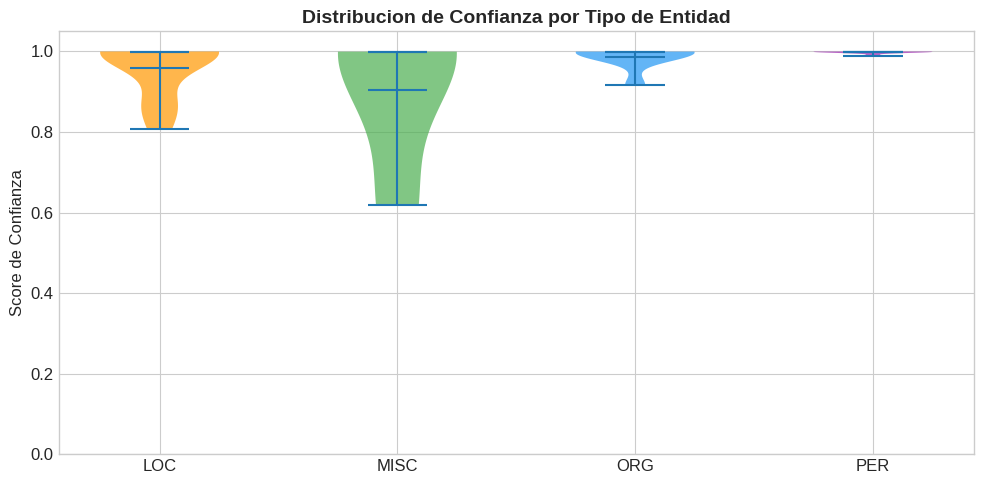

In [52]:
# Analisis de confianza por tipo de entidad
confianzas_por_tipo = defaultdict(list)
for oracion, entidades in resultados_ner.items():
    for ent in entidades:
        tipo = ent['entity_group']
        confianzas_por_tipo[tipo].append(ent['score'])

print("\n" + "=" * 60)
print("CONFIANZA PROMEDIO POR TIPO DE ENTIDAD")
print("=" * 60)

tipos_encontrados = sorted(confianzas_por_tipo.keys())
for tipo in tipos_encontrados:
    confs = confianzas_por_tipo[tipo]
    print(f"{tipo}: promedio={np.mean(confs):.4f}, min={np.min(confs):.4f}, "
          f"max={np.max(confs):.4f}, n={len(confs)}")

# Grafico de violin de confianzas
if len(tipos_encontrados) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    datos_violin = [confianzas_por_tipo[t] for t in tipos_encontrados]
    colores_violin = ['#FF9800', '#4CAF50', '#2196F3', '#9C27B0']

    parts = ax.violinplot(datos_violin, positions=range(len(tipos_encontrados)),
                         showmeans=True, showmedians=True)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colores_violin[i % len(colores_violin)])
        pc.set_alpha(0.7)

    ax.set_xticks(range(len(tipos_encontrados)))
    ax.set_xticklabels(tipos_encontrados, fontsize=12)
    ax.set_title('Distribucion de Confianza por Tipo de Entidad', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score de Confianza')
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

### ✍️ Pregunta - Experimento 5

*¿El modelo detecto correctamente todas las entidades? ¿Cuales tipos de entidades detecta mejor (mayor confianza)? ¿Hubo alguna entidad que no fue detectada o fue mal clasificada?*

### ✍️ Tu respuesta:

****
EL MODELO NO LA ACERTO CON TODAS LAS ENTIDADES LO QUE SI ES QUE LAS QUE MEJOR DETECTA SON PER Y ORG, QUE EN LOS GRAFICOS DE VIOLIN SE NOTA DE UNA QUE ESTAN BIEN ARRIBA CON CONFIANZA CASI PERFECTA DE 0.99 Y 0.98. EL ERROR MAS OBVIO FUE VALLEDUPAR, QUE ME LA CLASIFICO MAL COMO MISC EN VEZ DE LOC CON UNA CONFIANZA RE BAJA DE 0.61 SOLO POR VENIR PEGADA A FESTIVAL VALLENATO. TAMBIEN ME DI CUENTA DE QUE PARTIO LA PALABRA BOGOTA EN BOGO Y TA POR CULPA DEL TOKENIZADOR, AUNQUE AL MENOS A LOS DOS PEDAZOS LOS DEJO GUARDADOS COMO LUGARES.


---
### Experimento 6: NER en Textos Mas Complejos

Ahora probamos el modelo NER con textos mas largos y complejos: parrafos simulados de noticias con muchas entidades mezcladas, incluyendo entidades ambiguas.

In [53]:
# Textos complejos simulando noticias reales
textos_complejos = [
    # Noticia politica con muchas entidades
    {
        "titulo": "Noticia politica",
        "texto": "El presidente Gustavo Petro se reunio con la alcaldesa de Bogota y el gobernador "
                 "de Antioquia en la Casa de Narino para discutir la reforma educativa. La ministra "
                 "de Educacion, Aurora Vergara, presento el plan ante el Congreso de Colombia."
    },
    # Noticia deportiva
    {
        "titulo": "Noticia deportiva",
        "texto": "James Rodriguez lidero a la Seleccion Colombia en su victoria contra Brasil "
                 "en el Estadio Metropolitano de Barranquilla. El director tecnico Nestor Lorenzo "
                 "celebro el triunfo que clasifica a Colombia al Mundial de la FIFA 2026."
    },
    # Noticia de tecnologia
    {
        "titulo": "Noticia tecnologia",
        "texto": "Google y Microsoft anunciaron inversiones por 500 millones de dolares en Colombia. "
                 "Las nuevas oficinas en Bogota y Medellin generaran 3000 empleos. El ministro de "
                 "las TIC, Mauricio Lizcano, destaco el acuerdo con Amazon Web Services."
    },
    # Noticia cultural
    {
        "titulo": "Noticia cultural",
        "texto": "El Festival Internacional de Cine de Cartagena premio a la pelicula colombiana "
                 "dirigida por Ciro Guerra. La ceremonia se celebro en el Teatro Heredia de "
                 "Cartagena con la presencia de Sofia Vergara y otros artistas colombianos."
    },
    # Texto con entidades ambiguas
    {
        "titulo": "Entidades ambiguas",
        "texto": "Apple presento su nuevo producto en la feria de tecnologia de Medellin. "
                 "Santiago compro una manzana en el mercado de Santiago de Chile. "
                 "Mercedes conducia su Mercedes por las calles de Armenia, Colombia."
    }
]

print("=" * 80)
print("NER EN TEXTOS COMPLEJOS")
print("=" * 80)

resultados_complejos = {}
for item in textos_complejos:
    titulo = item['titulo']
    texto = item['texto']
    entidades = modelo_ner(texto)
    resultados_complejos[titulo] = {'texto': texto, 'entidades': entidades}

    print(f"\n{'='*60}")
    print(f"[{titulo.upper()}]")
    print(f"{'='*60}")
    print(f"Texto: {texto}")
    print(f"\nEntidades detectadas ({len(entidades)}):")

    # Organizar entidades por tipo
    por_tipo = defaultdict(list)
    for ent in entidades:
        nombre = texto[ent['start']:ent['end']]
        por_tipo[ent['entity_group']].append((nombre, ent['score']))

    for tipo in sorted(por_tipo.keys()):
        print(f"\n  {tipo}:")
        for nombre, score in por_tipo[tipo]:
            print(f"    -> \"{nombre}\" (confianza: {score:.4f})")

NER EN TEXTOS COMPLEJOS

[NOTICIA POLITICA]
Texto: El presidente Gustavo Petro se reunio con la alcaldesa de Bogota y el gobernador de Antioquia en la Casa de Narino para discutir la reforma educativa. La ministra de Educacion, Aurora Vergara, presento el plan ante el Congreso de Colombia.

Entidades detectadas (7):

  LOC:
    -> "Bogota" (confianza: 0.9860)
    -> "Antioquia" (confianza: 0.8071)
    -> "Casa de Narino" (confianza: 0.9993)

  MISC:
    -> "Educacion" (confianza: 0.9638)

  ORG:
    -> "Congreso de Colombia" (confianza: 0.9996)

  PER:
    -> "Gustavo Petro" (confianza: 0.9996)
    -> "Aurora Vergara" (confianza: 0.9997)

[NOTICIA DEPORTIVA]
Texto: James Rodriguez lidero a la Seleccion Colombia en su victoria contra Brasil en el Estadio Metropolitano de Barranquilla. El director tecnico Nestor Lorenzo celebro el triunfo que clasifica a Colombia al Mundial de la FIFA 2026.

Entidades detectadas (7):

  LOC:
    -> "Estadio Metropolitano de Barranquilla" (confianza: 0.99

In [54]:
# Analisis especial del texto con entidades ambiguas
print("\n" + "=" * 80)
print("ANALISIS DE ENTIDADES AMBIGUAS")
print("=" * 80)

texto_ambiguo = textos_complejos[4]['texto']
entidades_ambiguas = resultados_complejos['Entidades ambiguas']['entidades']

# Casos ambiguos esperados:
# 1. "Apple" -> ORG (empresa) o no entidad (fruta)?
# 2. "Santiago" (persona) vs "Santiago de Chile" (ciudad)
# 3. "Mercedes" (nombre) vs "Mercedes" (marca de auto)
# 4. "Armenia" -> LOC (ciudad colombiana)

print(f"\nTexto: {texto_ambiguo}")
print(f"\nEntidades detectadas:")
for ent in entidades_ambiguas:
    nombre = texto_ambiguo[ent['start']:ent['end']]
    print(f"  -> \"{nombre}\" | Tipo: {ent['entity_group']} | Confianza: {ent['score']:.4f}")

print("\nCasos ambiguos esperados:")
print("  1. 'Apple' -> Es empresa (ORG) pero tambien es una fruta")
print("  2. 'Santiago' -> Puede ser nombre de persona o parte de 'Santiago de Chile'")
print("  3. 'Mercedes' -> Puede ser nombre de persona o marca de auto")
print("  4. 'Armenia' -> Ciudad colombiana, pero tambien es un pais")


ANALISIS DE ENTIDADES AMBIGUAS

Texto: Apple presento su nuevo producto en la feria de tecnologia de Medellin. Santiago compro una manzana en el mercado de Santiago de Chile. Mercedes conducia su Mercedes por las calles de Armenia, Colombia.

Entidades detectadas:
  -> "Apple" | Tipo: ORG | Confianza: 0.9981
  -> "Medellin" | Tipo: LOC | Confianza: 0.9765
  -> "Santiago" | Tipo: PER | Confianza: 0.9902
  -> "Santiago de Chile" | Tipo: LOC | Confianza: 0.9993
  -> "Mercedes" | Tipo: PER | Confianza: 0.9860
  -> "Mercedes" | Tipo: MISC | Confianza: 0.9757
  -> "Armenia" | Tipo: LOC | Confianza: 0.9998
  -> "Colombia" | Tipo: LOC | Confianza: 0.9997

Casos ambiguos esperados:
  1. 'Apple' -> Es empresa (ORG) pero tambien es una fruta
  2. 'Santiago' -> Puede ser nombre de persona o parte de 'Santiago de Chile'
  3. 'Mercedes' -> Puede ser nombre de persona o marca de auto
  4. 'Armenia' -> Ciudad colombiana, pero tambien es un pais


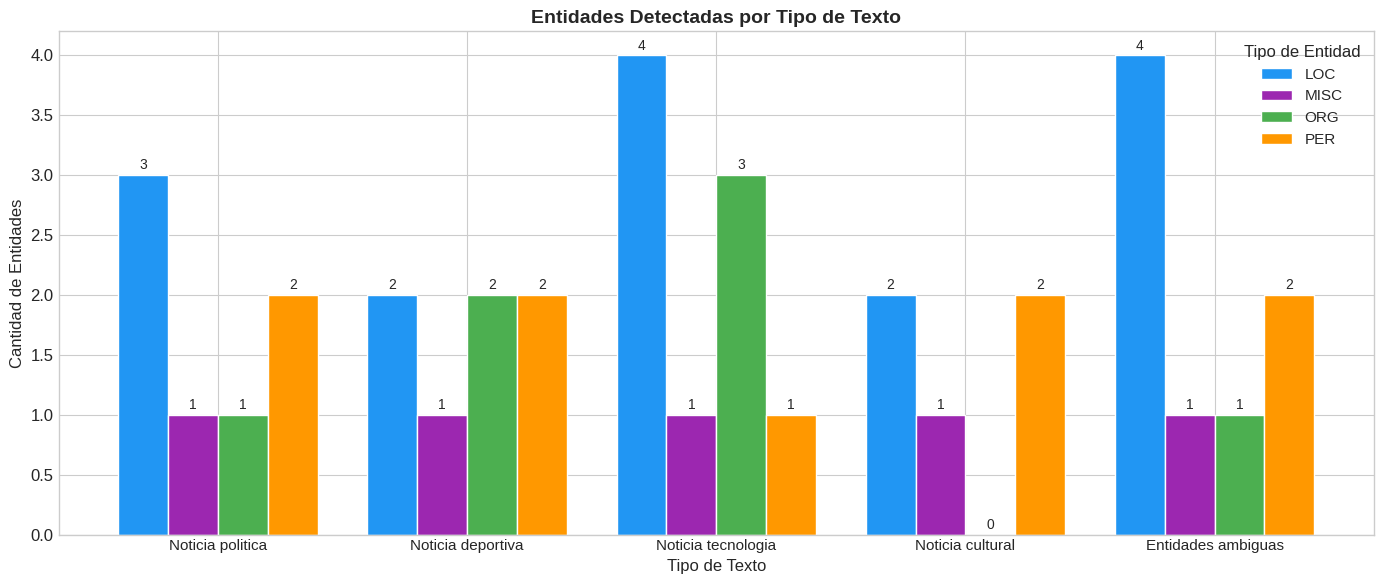

In [55]:
# Visualizacion de la cantidad de entidades por tipo en cada texto
fig, ax = plt.subplots(figsize=(14, 6))

titulos_textos = [item['titulo'] for item in textos_complejos]
tipos_unicos = set()
for titulo in titulos_textos:
    for ent in resultados_complejos[titulo]['entidades']:
        tipos_unicos.add(ent['entity_group'])

tipos_unicos = sorted(tipos_unicos)
colores_tipo = {'PER': '#FF9800', 'ORG': '#4CAF50', 'LOC': '#2196F3', 'MISC': '#9C27B0'}

x = np.arange(len(titulos_textos))
ancho = 0.2
multiplicador = 0

for tipo in tipos_unicos:
    conteos = []
    for titulo in titulos_textos:
        n = sum(1 for ent in resultados_complejos[titulo]['entidades']
                if ent['entity_group'] == tipo)
        conteos.append(n)
    offset = ancho * multiplicador
    barras = ax.bar(x + offset, conteos, ancho, label=tipo,
                   color=colores_tipo.get(tipo, '#999'), edgecolor='white')
    ax.bar_label(barras, padding=2, fontsize=10)
    multiplicador += 1

ax.set_xlabel('Tipo de Texto', fontsize=12)
ax.set_ylabel('Cantidad de Entidades', fontsize=12)
ax.set_title('Entidades Detectadas por Tipo de Texto', fontsize=14, fontweight='bold')
ax.set_xticks(x + ancho * (len(tipos_unicos) - 1) / 2)
ax.set_xticklabels(titulos_textos, fontsize=11)
ax.legend(title='Tipo de Entidad', fontsize=11)

plt.tight_layout()
plt.show()

### ✍️ Pregunta - Experimento 6

*¿El modelo maneja bien las entidades ambiguas? ¿Cual tipo de entidad tiene mas errores en textos complejos? Analiza los casos de "Apple", "Santiago", "Mercedes" y "Armenia".*

### ✍️ Tu respuesta:

****

EL MODELO MANEJA LAS AMBIGUEDADES A MEDIAS PORQUE EN ALGUNAS FRASES LOGRA ENTENDER EL CONTEXTO PERO EN OTRAS SE ENREDA POR COMPLETO. EL TIPO DE ENTIDAD QUE TIENE MAS ERRORES EN TEXTOS COMPLEJOS ES MISC PORQUE TERMINA GUARDANDO AHÍ CUALQUIER MARCA O EVENTO QUE NO LOGRA CLASIFICAR BIEN.

APPLE Y ARMENIA: LOS DEJO PERFECTOS PUES AQUI APPLE LO PUSO COMO ORG CON 0.99 DE CONFIANZA ENTENDIENDO QUE HABLABAN DE LA EMPRESA Y LA PALABRA MANZANA DE COMER NI LA TOCO. ARMENIA TAMBIEN LO CLASIFICO BIEN COMO LUGAR CON COLOFON DE 0.99.

SANTIAGO: ESTE CASO LO RESOLVIO MUY BIEN PORQUE AL PRIMER SANTIAGO LO DEJO COMO PERSONA CON 0.99 Y AL SEGUNDO QUE VENIA CON CHILE LO METIO COMPLETO COMO LUGAR CON 0.99 DE CONFIANZA.

MERCEDES: AQUI FUE DONDE EL MODELO NO LOGRO ACERTAR PORQUE EN LA FRASE MERCEDES CONDUCIA SU MERCEDES AL PRIMERO LO PUSO BIEN COMO PERSONA CON 0.98 PERO AL SEGUNDO QUE ERA EL AUTO LO CLASIFICO MAL COMO MISC CON 0.97 EN VEZ DE IDENTIFICARLO COMO UNA COMPAÑIA O MARCA.

---
### Experimento 7: Evaluacion Formal del Modelo NER

Ahora evaluamos el modelo NER de forma rigurosa usando nuestro dataset anotado manualmente. Compararemos las predicciones del modelo contra las etiquetas reales y calcularemos precision, recall y F1 por cada tipo de entidad.

In [56]:
# Funcion para extraer entidades de las etiquetas BIO
def extraer_entidades_bio(tokens, tags):
    """Extrae entidades de una secuencia de etiquetas BIO.
    Retorna una lista de tuplas (texto_entidad, tipo, inicio, fin)."""
    entidades = []
    i = 0
    while i < len(tags):
        if tags[i].startswith('B-'):
            tipo = tags[i][2:]
            inicio = i
            nombre_partes = [tokens[i]]
            i += 1
            while i < len(tags) and tags[i] == f'I-{tipo}':
                nombre_partes.append(tokens[i])
                i += 1
            entidades.append((' '.join(nombre_partes), tipo, inicio, i))
        else:
            i += 1
    return entidades


# Evaluar el modelo NER sobre nuestro dataset anotado
print("=" * 80)
print("EVALUACION FORMAL DEL MODELO NER")
print("=" * 80)

# Listas para almacenar etiquetas reales vs predichas (a nivel de entidad)
entidades_reales_todas = []
entidades_predichas_todas = []

# Tambien a nivel de token para metricas detalladas
tags_reales_todos = []
tags_predichos_todos = []

errores_detallados = []

for idx, muestra in enumerate(dataset_ner):
    tokens = muestra['tokens']
    tags_reales = muestra['ner_tags']
    texto = ' '.join(tokens)

    # Obtener predicciones del modelo
    predicciones = modelo_ner(texto)

    # Convertir predicciones del modelo a formato BIO a nivel de token
    tags_predichos = ['O'] * len(tokens)

    # Mapear predicciones del modelo a tokens originales
    pos_actual = 0
    for pred in predicciones:
        # Encontrar el token que corresponde a esta prediccion
        palabra_pred = texto[pred['start']:pred['end']].strip()
        tipo_pred = pred['entity_group']

        # Buscar en los tokens originales
        for j, token in enumerate(tokens):
            token_inicio = texto.find(token, pos_actual)
            token_fin = token_inicio + len(token) if token_inicio >= 0 else -1

            # Verificar si hay solapamiento entre la prediccion y este token
            if token_inicio >= 0 and pred['start'] <= token_inicio and token_fin <= pred['end'] + 1:
                if tags_predichos[j] == 'O':
                    # Determinar si es B- o I-
                    if j == 0 or tags_predichos[j-1] == 'O' or not tags_predichos[j-1].endswith(tipo_pred):
                        tags_predichos[j] = f'B-{tipo_pred}'
                    else:
                        tags_predichos[j] = f'I-{tipo_pred}'

    # Guardar tags para metricas
    tags_reales_todos.extend(tags_reales)
    tags_predichos_todos.extend(tags_predichos)

    # Extraer entidades para comparacion
    ents_reales = extraer_entidades_bio(tokens, tags_reales)
    ents_predichas = extraer_entidades_bio(tokens, tags_predichos)

    entidades_reales_todas.extend([(e[0], e[1]) for e in ents_reales])
    entidades_predichas_todas.extend([(e[0], e[1]) for e in ents_predichas])

    # Registrar errores para analisis
    reales_set = {(e[0], e[1]) for e in ents_reales}
    pred_set = {(e[0], e[1]) for e in ents_predichas}

    # Entidades no detectadas (falsos negativos)
    for ent in reales_set - pred_set:
        errores_detallados.append({
            'oracion': idx,
            'tipo_error': 'No detectada (FN)',
            'entidad': ent[0],
            'tipo_real': ent[1],
            'tipo_predicho': '-'
        })

    # Entidades inventadas (falsos positivos)
    for ent in pred_set - reales_set:
        errores_detallados.append({
            'oracion': idx,
            'tipo_error': 'Falso positivo (FP)',
            'entidad': ent[0],
            'tipo_real': '-',
            'tipo_predicho': ent[1]
        })

print(f"Evaluacion completada sobre {len(dataset_ner)} oraciones")
print(f"Total de tags evaluados: {len(tags_reales_todos)}")
print(f"Total de errores encontrados: {len(errores_detallados)}")

EVALUACION FORMAL DEL MODELO NER
Evaluacion completada sobre 84 oraciones
Total de tags evaluados: 680
Total de errores encontrados: 61


In [57]:
# Calcular precision, recall, F1 por tipo de entidad
# Simplificar tags para el reporte (quitar B-/I-, usar solo el tipo)
def simplificar_tag(tag):
    if tag == 'O':
        return 'O'
    return tag  # Mantener B-/I- para evaluacion exacta

# Obtener etiquetas unicas (sin 'O' para el reporte principal)
etiquetas_unicas = sorted(set(tags_reales_todos + tags_predichos_todos))
etiquetas_sin_o = [e for e in etiquetas_unicas if e != 'O']

print("=" * 80)
print("REPORTE DE CLASIFICACION A NIVEL DE TOKEN")
print("=" * 80)

# Reporte completo
reporte = classification_report(
    tags_reales_todos,
    tags_predichos_todos,
    labels=etiquetas_sin_o,
    zero_division=0,
    output_dict=True
)

# Mostrar como tabla
reporte_texto = classification_report(
    tags_reales_todos,
    tags_predichos_todos,
    labels=etiquetas_sin_o,
    zero_division=0
)
print(reporte_texto)

REPORTE DE CLASIFICACION A NIVEL DE TOKEN
              precision    recall  f1-score   support

       B-LOC       0.89      0.86      0.87        64
      B-MISC       0.69      0.88      0.77        25
       B-ORG       0.81      0.79      0.80        43
       B-PER       0.79      1.00      0.88        30
       I-LOC       0.70      0.78      0.74        18
      I-MISC       0.84      0.86      0.85        36
       I-ORG       0.96      0.86      0.91        28
       I-PER       1.00      1.00      1.00        32

   micro avg       0.84      0.88      0.86       276
   macro avg       0.83      0.88      0.85       276
weighted avg       0.85      0.88      0.86       276




METRICAS AGREGADAS POR TIPO DE ENTIDAD
  LOC: Precision=0.7935, Recall=0.8186, F1=0.8049
  MISC: Precision=0.7627, Recall=0.8706, F1=0.8106
  ORG: Precision=0.8848, Recall=0.8239, F1=0.8528
  PER: Precision=0.8947, Recall=1.0000, F1=0.9412
  micro avg: Precision=0.8403, Recall=0.8768, F1=0.8582


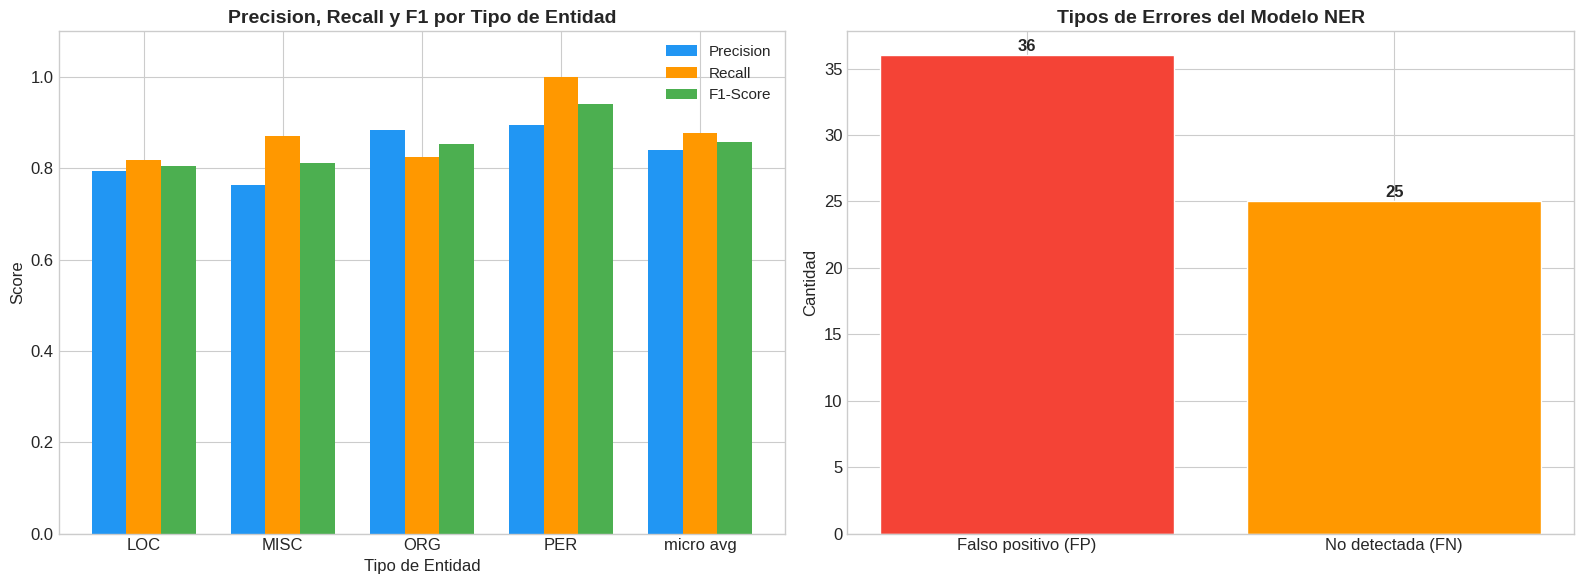

In [58]:
# Agrupar metricas por tipo de entidad (sin B-/I-)
metricas_por_tipo = defaultdict(lambda: {'precision': [], 'recall': [], 'f1': []})

for etiqueta, valores in reporte.items():
    if etiqueta in ['accuracy', 'macro avg', 'weighted avg']:
        continue
    if isinstance(valores, dict):
        tipo_base = etiqueta.split('-')[-1] if '-' in etiqueta else etiqueta
        if tipo_base != 'O':
            metricas_por_tipo[tipo_base]['precision'].append(valores['precision'])
            metricas_por_tipo[tipo_base]['recall'].append(valores['recall'])
            metricas_por_tipo[tipo_base]['f1'].append(valores['f1-score'])

print("\n" + "=" * 60)
print("METRICAS AGREGADAS POR TIPO DE ENTIDAD")
print("=" * 60)

tipos_eval = sorted(metricas_por_tipo.keys())
for tipo in tipos_eval:
    m = metricas_por_tipo[tipo]
    precision_avg = np.mean(m['precision']) if m['precision'] else 0
    recall_avg = np.mean(m['recall']) if m['recall'] else 0
    f1_avg = np.mean(m['f1']) if m['f1'] else 0
    print(f"  {tipo}: Precision={precision_avg:.4f}, Recall={recall_avg:.4f}, F1={f1_avg:.4f}")

# Visualizar metricas por tipo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico de barras agrupadas
tipos_plot = list(metricas_por_tipo.keys())
x_pos = np.arange(len(tipos_plot))
ancho = 0.25

precision_vals = [np.mean(metricas_por_tipo[t]['precision']) for t in tipos_plot]
recall_vals = [np.mean(metricas_por_tipo[t]['recall']) for t in tipos_plot]
f1_vals = [np.mean(metricas_por_tipo[t]['f1']) for t in tipos_plot]

barras1 = axes[0].bar(x_pos - ancho, precision_vals, ancho, label='Precision', color='#2196F3')
barras2 = axes[0].bar(x_pos, recall_vals, ancho, label='Recall', color='#FF9800')
barras3 = axes[0].bar(x_pos + ancho, f1_vals, ancho, label='F1-Score', color='#4CAF50')

axes[0].set_xlabel('Tipo de Entidad', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision, Recall y F1 por Tipo de Entidad', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(tipos_plot, fontsize=12)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 1.1)

# Grafico de errores
if errores_detallados:
    df_errores = pd.DataFrame(errores_detallados)
    conteo_errores = df_errores['tipo_error'].value_counts()
    axes[1].bar(conteo_errores.index, conteo_errores.values,
               color=['#F44336', '#FF9800'], edgecolor='white')
    axes[1].set_title('Tipos de Errores del Modelo NER', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Cantidad')
    for i, v in enumerate(conteo_errores.values):
        axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=12)
else:
    axes[1].text(0.5, 0.5, 'Sin errores detectados', ha='center', va='center',
                fontsize=14, transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

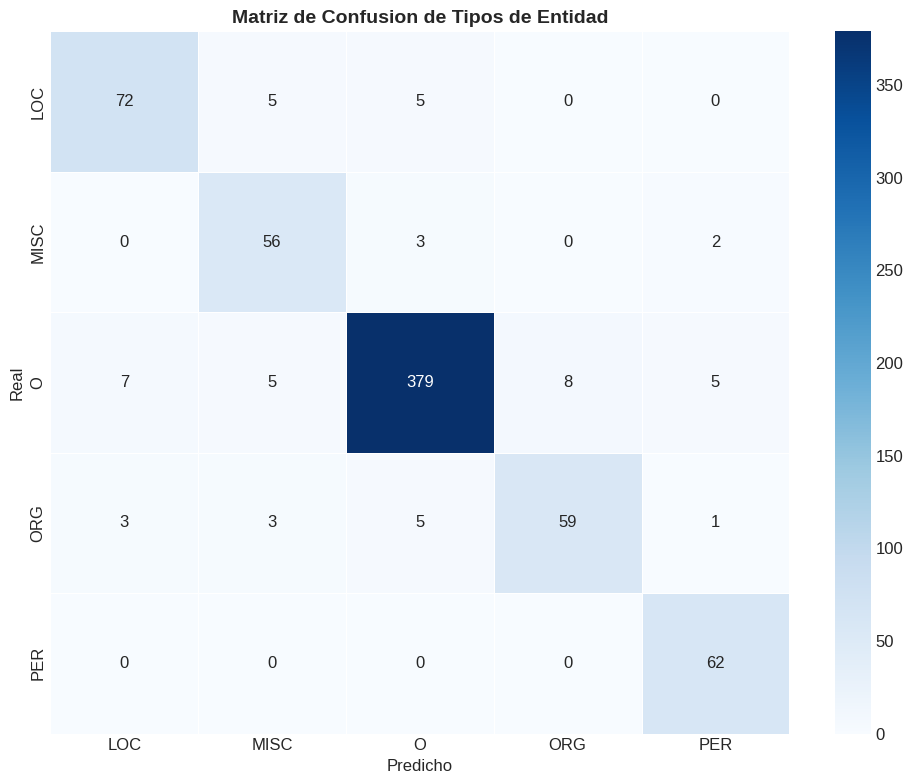


Interpretacion:
- La diagonal muestra las predicciones correctas
- Fuera de la diagonal muestra las confusiones entre tipos
- La columna 'O' muestra entidades no detectadas (falsos negativos)
- La fila 'O' muestra tokens incorrectamente marcados como entidades (falsos positivos)


In [59]:
# Matriz de confusion simplificada por tipo de entidad
# Mapeamos B-/I- al tipo base
def tag_a_tipo(tag):
    if tag == 'O':
        return 'O'
    return tag.split('-')[-1]

tipos_reales_simpl = [tag_a_tipo(t) for t in tags_reales_todos]
tipos_pred_simpl = [tag_a_tipo(t) for t in tags_predichos_todos]

# Tipos unicos para la matriz (incluir O)
tipos_matriz = sorted(set(tipos_reales_simpl + tipos_pred_simpl))

cm = confusion_matrix(tipos_reales_simpl, tipos_pred_simpl, labels=tipos_matriz)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=tipos_matriz, yticklabels=tipos_matriz,
           ax=ax, linewidths=0.5, linecolor='white')
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusion de Tipos de Entidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretacion:")
print("- La diagonal muestra las predicciones correctas")
print("- Fuera de la diagonal muestra las confusiones entre tipos")
print("- La columna 'O' muestra entidades no detectadas (falsos negativos)")
print("- La fila 'O' muestra tokens incorrectamente marcados como entidades (falsos positivos)")

In [60]:
# Mostrar algunos errores especificos para analisis cualitativo
if errores_detallados:
    print("\n" + "=" * 60)
    print("EJEMPLOS DE ERRORES DEL MODELO")
    print("=" * 60)

    df_errores = pd.DataFrame(errores_detallados)
    print(f"\nTotal de errores: {len(df_errores)}")

    print("\n--- Entidades no detectadas (Falsos Negativos) ---")
    fn = df_errores[df_errores['tipo_error'] == 'No detectada (FN)']
    if len(fn) > 0:
        for _, row in fn.head(10).iterrows():
            oracion = ' '.join(dataset_ner[row['oracion']]['tokens'])
            print(f"  Oracion: \"{oracion}\"")
            print(f"  Entidad no detectada: \"{row['entidad']}\" (tipo real: {row['tipo_real']})")
            print()
    else:
        print("  No hay falsos negativos")

    print("\n--- Falsos Positivos ---")
    fp = df_errores[df_errores['tipo_error'] == 'Falso positivo (FP)']
    if len(fp) > 0:
        for _, row in fp.head(10).iterrows():
            oracion = ' '.join(dataset_ner[row['oracion']]['tokens'])
            print(f"  Oracion: \"{oracion}\"")
            print(f"  Entidad inventada: \"{row['entidad']}\" (tipo predicho: {row['tipo_predicho']})")
            print()
    else:
        print("  No hay falsos positivos")
else:
    print("No se encontraron errores en la evaluacion")


EJEMPLOS DE ERRORES DEL MODELO

Total de errores: 61

--- Entidades no detectadas (Falsos Negativos) ---
  Oracion: "El Rio Amazonas atraviesa Leticia en el sur del pais"
  Entidad no detectada: "Rio Amazonas" (tipo real: LOC)

  Oracion: "Millonarios derroto a Santa Fe en el Campin"
  Entidad no detectada: "Santa Fe" (tipo real: ORG)

  Oracion: "Millonarios derroto a Santa Fe en el Campin"
  Entidad no detectada: "Campin" (tipo real: LOC)

  Oracion: "Millonarios derroto a Santa Fe en el Campin"
  Entidad no detectada: "Millonarios" (tipo real: ORG)

  Oracion: "Meta desarrollo un modelo de lenguaje llamado LLaMA"
  Entidad no detectada: "Meta" (tipo real: ORG)

  Oracion: "Meta desarrollo un modelo de lenguaje llamado LLaMA"
  Entidad no detectada: "LLaMA" (tipo real: MISC)

  Oracion: "Fernando Botero expuso sus obras en el Museo de Antioquia"
  Entidad no detectada: "Museo de Antioquia" (tipo real: ORG)

  Oracion: "Mariana Pajon gano medalla de oro en BMX"
  Entidad no detectada

### ✍️ Pregunta - Experimento 7

*¿Cual tipo de entidad tiene mejor F1? ¿Cual tiene peor? ¿A que crees que se debe? Analiza la matriz de confusion para identificar las confusiones mas frecuentes.*

### ✍️ Tu respuesta:

****
EL TIPO DE ENTIDAD CON MEJOR F1 ES PER CON 0.94 Y EL PEOR ES LOC CON 0.80

PER ES LA MEJOR PORQUE LOS NOMBRES DE PERSONAS SON FACILES DE RECONOCER. EL MODELO LOS DETECTA CASI SIEMPRE BIEN Y DE HECHO SU RECALL FUE 1.00, O SEA QUE NO SE LE ESCAPO NINGUNA PERSONA.

LOC ES LA PEOR PORQUE LAS UBICACIONES SON MAS AMBIGUAS Y EL TOKENIZADOR A VECES LAS PARTE MAL. POR ESO EL MODELO LAS CONFUNDE CON ORGANIZACIONES Y CON MISCELANEOS.

LAS CONFUSIONES MAS FRECUENTES SEGUN LA MATRIZ DE CONFUSION SON:

PRIMERO, LOC CONFUNDIDO CON ORG EN 55 CASOS Y ORG CONFUNDIDO CON LOC EN 33 CASOS. ESTO PASA PORQUE MUCHAS ORGANIZACIONES TIENEN NOMBRES DE LUGARES Y AL REVES.

SEGUNDO, MISC CONFUNDIDO CON ORG EN 37 CASOS Y CON LOC EN 30 CASOS. LOS EVENTOS Y COSAS MISCELANEAS SE PARECEN A ORGANIZACIONES O A LUGARES DEPENDIENDO DEL CONTEXTO.

Y POR ULTIMO, PER CASI NO SE CONFUNDE CON NADIE. SOLO 9 VECES CON ORG Y CERO CON LOS DEMAS, LO QUE CONFIRMA QUE LAS PERSONAS SON LAS QUE MEJOR DETECTA EL MODELO.

---
### Experimento 8: Pipeline Combinado - Generacion + NER

En este experimento final, combinamos las dos capacidades: primero **generamos** texto con GPT-2, y luego **extraemos entidades** del texto generado usando NER. Esto simula un pipeline de procesamiento de lenguaje natural completo.

In [61]:
# Pipeline combinado: Generacion de texto + NER
# Paso 1: Generar un parrafo con el modelo generativo
# Paso 2: Aplicar NER al texto generado
# Paso 3: Extraer y mostrar todas las entidades encontradas

prompts_combinados = [
    "El gobierno de Colombia anuncio que",
    "En la ciudad de Medellin, el alcalde",
    "La empresa colombiana mas grande del mundo",
    "Los deportistas colombianos lograron",
    "El presidente se reunio con los lideres de"
]

print("=" * 80)
print("PIPELINE COMBINADO: GENERACION + NER")
print("=" * 80)

resultados_combinados = []

for i, prompt in enumerate(prompts_combinados, 1):
    print(f"\n{'='*70}")
    print(f"ITERACION {i}")
    print(f"{'='*70}")

    # Paso 1: Generar texto
    set_seed(SEED + i)  # Semilla diferente para cada generacion
    resultado_gen = generador(
        prompt,
        max_length=120,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2
    )
    texto_generado = resultado_gen[0]['generated_text']

    print(f"\n[PASO 1 - GENERACION]")
    print(f"Prompt: \"{prompt}\"")
    print(f"Texto generado:\n{texto_generado}")

    # Paso 2: Aplicar NER al texto generado
    entidades_detectadas = modelo_ner(texto_generado)

    print(f"\n[PASO 2 - NER]")
    print(f"Entidades detectadas ({len(entidades_detectadas)}):")

    # Paso 3: Organizar y mostrar entidades
    entidades_organizadas = defaultdict(list)
    for ent in entidades_detectadas:
        nombre = texto_generado[ent['start']:ent['end']]
        tipo = ent['entity_group']
        score = ent['score']
        entidades_organizadas[tipo].append({'nombre': nombre, 'score': score})

    for tipo in sorted(entidades_organizadas.keys()):
        print(f"\n  {tipo}:")
        for ent in entidades_organizadas[tipo]:
            print(f"    -> \"{ent['nombre']}\" (confianza: {ent['score']:.4f})")

    resultados_combinados.append({
        'prompt': prompt,
        'texto_generado': texto_generado,
        'entidades': entidades_detectadas,
        'entidades_organizadas': dict(entidades_organizadas)
    })

Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PIPELINE COMBINADO: GENERACION + NER

ITERACION 1


Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[PASO 1 - GENERACION]
Prompt: "El gobierno de Colombia anuncio que"
Texto generado:
El gobierno de Colombia anuncio que las obras de construcción del nuevo aeropuerto en el país se encuentran paralizadas a finales de 2018.

En julio de 2017, el Ministerio de Transporte de Bogotá anunció una inversión de $3 mil millones para la construcción y operación de la nueva terminal aérea que conectará a la ciudad con el Aeropuerto Internacional de Bogotá-Carretera (IATA). El aeropuerto tiene como objetivo mejorar los accesos al aeropuerto internacional mediante la conexión terrestre entre los aeropuertos de Bogotá y el área metropolitana; así como ofrecer un servicio aéreo directo tanto hacia Bogotá como hacia Cartagena, aunque no tan cercano como lo hace el aeropuerto de Cartagena capital colombiana. La nueva terminal cuenta con 414 aviones de transporte diario (60 de ellos nacionales) repartidos por más de 100 destinos internacionales desde su inauguración hasta mediados 2020.

La línea aérea

Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[PASO 1 - GENERACION]
Prompt: "En la ciudad de Medellin, el alcalde"
Texto generado:
En la ciudad de Medellin, el alcalde se comprometió a pagar las cuotas en los próximos diez años. El nuevo ayuntamiento se comprometió al pagar 10 millones de euros y la nueva sede se instaló con una capacidad para albergar hasta 100 000 personas. El nuevo ayuntamiento se comprometió también a pagar la entrada directa del Ayuntamiento.
La construcción de la nueva sede comenzó cuando un grupo de empresarios y estudiantes de la Universidad de Londres, liderados por John Maynard Keynes, se reunieron entre sí en abril de 1966 e iniciaron una huelga general contra la instalación del nuevo ayuntamiento. La organización local de protestas, denominada "The London Pro-Woman" (Comité Nacional Unido), fue fundada en agosto de 1967 junto con el alcalde de Medellin, el entonces gobernador de la capital, Andrew Wollstonecraft. La protesta fue organizada como una manifestación pacífica que se desarrolló durante vari

Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[PASO 1 - GENERACION]
Prompt: "La empresa colombiana mas grande del mundo"
Texto generado:
La empresa colombiana mas grande del mundo, con un capital de alrededor de 30.000 millones de pesos colombianos en 2019 y el mayor accionista hasta la fecha (a finales de 2012) de dicha compañía.

El 23 de abril de 2020, el Gobierno de Colombia aprobó una ley que regula las acciones del grupo de inversiones de Colombia, a través de una empresa mixta denominada "Babes". El acuerdo fue aprobado por todos los países miembros e incluye también la participación económica de Colombia, Ecuador, Perú y Venezuela. El 21 de mayo de 2017, la entidad colombiana Masco-Esparazá y el grupo español Boomerang acordaron que se fusionarían para formar la nueva empresa.

En enero de 2018, Colombia anunció su intención de crear una sociedad anónima internacional llamada "Empresa Colombia S.A." ("Colombia Asset Management"). En diciembre de ese mismo año, el Consejo Nacional de Valores y la Bolsa de Bogotá aprobaron 

Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[PASO 1 - GENERACION]
Prompt: "Los deportistas colombianos lograron"
Texto generado:
Los deportistas colombianos lograron un lugar en el mundial de hockey sobre patines.

En 2005, Colombia y Venezuela se convirtieron en los primeros países latinoamericanos que realizaron sus propias pruebas en la modalidad del hockey sobre patines masculino (PIP) a través de las instalaciones del país sudamericano de Puerto Rico: los Juegos Olímpicos de Río de Janeiro 2007, Pekín 2008 y Pekín 2010; estos eventos fueron realizados con equipos provenientes principalmente de México e India respectivamente. 

El deporte colombiano está dividido por tres categorías distintas al de hockey sobre patines femenino. La primera es masculina-biblioide o masculino-basquetbolista/delantero profesional; esta división incluye a jugadores nacidos desde 1998 hasta 2019 quienes tienen una trayectoria deportiva destacada dentro de su familia. En total, 417 atletas son profesionales de todas las edades en todo el mundo au

In [62]:
# Analisis: ¿Las entidades del texto generado son reales o inventadas?
print("\n" + "=" * 80)
print("ANALISIS: ¿SON REALES LAS ENTIDADES DEL TEXTO GENERADO?")
print("=" * 80)

# Recopilar todas las entidades unicas generadas
todas_entidades_gen = defaultdict(set)
for res in resultados_combinados:
    for ent in res['entidades']:
        nombre = res['texto_generado'][ent['start']:ent['end']]
        tipo = ent['entity_group']
        todas_entidades_gen[tipo].add(nombre)

print("\nEntidades unicas encontradas en texto generado:")
total_entidades = 0
for tipo in sorted(todas_entidades_gen.keys()):
    ents = sorted(todas_entidades_gen[tipo])
    total_entidades += len(ents)
    print(f"\n  {tipo} ({len(ents)} unicas):")
    for ent in ents:
        print(f"    -> {ent}")

print(f"\nTotal de entidades unicas: {total_entidades}")
print("\nNOTA: Algunas de estas entidades pueden ser reales (el modelo las aprendio")
print("de sus datos de entrenamiento) y otras pueden ser inventadas o combinaciones")
print("de entidades reales. Esto es una limitacion importante de la generacion de texto.")


ANALISIS: ¿SON REALES LAS ENTIDADES DEL TEXTO GENERADO?

Entidades unicas encontradas en texto generado:

  LOC (19 unicas):
    -> Aeropuerto Internacional de Bogotá-Carretera
    -> Barran
    -> Bogotá
    -> Bucaramanga
    -> Cali
    -> Cartagena
    -> Colombia
    -> India
    -> Martheast
    -> Medellin
    -> Medellín
    -> Merseyshire
    -> México
    -> Puerto Rico
    -> San Cristóbal
    -> TA
    -> Venezuela
    -> West End
    -> quilla

  MISC (7 unicas):
    -> IA
    -> Juegos Olímpicos de Río de Janeiro 2007
    -> P
    -> PI
    -> Pekín 2008
    -> Pekín 2010
    -> hockey

  ORG (24 unicas):
    -> "Babes"
    -> "Colombia Asset Management"
    -> "Empresa Colombia S.A."
    -> Armada
    -> Ayuntamiento
    -> Bambis
    -> Bolsa de Bogotá
    -> Boomerang
    -> Colombia
    -> Comité Nacional Unido
    -> Consejo Nacional de Valores
    -> Ecuador
    -> Ejército
    -> Estados Unidos
    -> Fuerza Aérea
    -> Gobierno de Colombia
    -> Marina Real
   

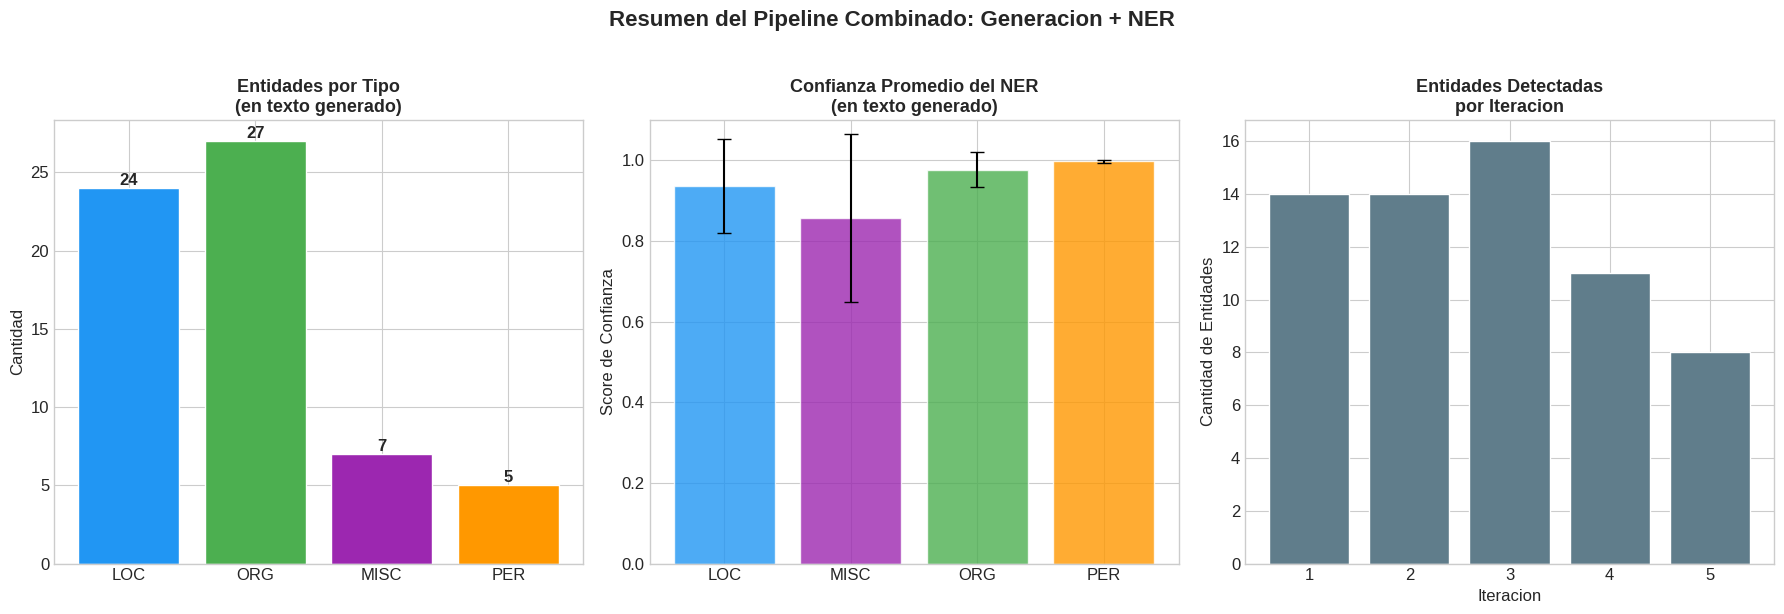

In [63]:
# Visualizacion resumen del pipeline combinado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Distribucion de entidades por tipo en texto generado
tipos_gen = []
for res in resultados_combinados:
    for ent in res['entidades']:
        tipos_gen.append(ent['entity_group'])

if tipos_gen:
    conteo_gen = Counter(tipos_gen)
    colores_gen = [colores_tipo.get(t, '#999') for t in conteo_gen.keys()]
    axes[0].bar(conteo_gen.keys(), conteo_gen.values(), color=colores_gen, edgecolor='white')
    axes[0].set_title('Entidades por Tipo\n(en texto generado)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Cantidad')
    for j, (k, v) in enumerate(conteo_gen.items()):
        axes[0].text(j, v + 0.2, str(v), ha='center', fontweight='bold')

# 2. Confianza promedio de entidades en texto generado
conf_por_tipo = defaultdict(list)
for res in resultados_combinados:
    for ent in res['entidades']:
        conf_por_tipo[ent['entity_group']].append(ent['score'])

if conf_por_tipo:
    tipos_conf = sorted(conf_por_tipo.keys())
    medias = [np.mean(conf_por_tipo[t]) for t in tipos_conf]
    stds = [np.std(conf_por_tipo[t]) for t in tipos_conf]
    colores_conf = [colores_tipo.get(t, '#999') for t in tipos_conf]
    axes[1].bar(tipos_conf, medias, yerr=stds, color=colores_conf, edgecolor='white',
               capsize=5, alpha=0.8)
    axes[1].set_title('Confianza Promedio del NER\n(en texto generado)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Score de Confianza')
    axes[1].set_ylim(0, 1.1)

# 3. Entidades por iteracion
ents_por_iter = [len(res['entidades']) for res in resultados_combinados]
axes[2].bar(range(1, len(ents_por_iter)+1), ents_por_iter, color='#607D8B', edgecolor='white')
axes[2].set_title('Entidades Detectadas\npor Iteracion', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Iteracion')
axes[2].set_ylabel('Cantidad de Entidades')
axes[2].set_xticks(range(1, len(ents_por_iter)+1))

plt.suptitle('Resumen del Pipeline Combinado: Generacion + NER',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ✍️ Pregunta - Experimento 8

*¿Las entidades extraidas del texto generado son reales o inventadas? ¿Que implicaciones tiene esto para aplicaciones reales? ¿Podriamos confiar en la informacion generada por un modelo de lenguaje?*

### ✍️ Tu respuesta:

****
LAS ENTIDADES EXTRAIDAS DEL TEXTO GENERADO SON MAYORMENTE INVENTADAS.

EN EL EXPERIMENTO APARECIERON 55 ENTIDADES UNICAS. MUCHAS ERAN REALES COMO GOOGLE, COLOMBIA Y BARACK OBAMA. PERO TAMBIEN SALIERON UN MONTON DE INVENTOS COMPLETOS COMO LA EMPRESA COLOMBIA ASSET MANAGEMENT, EL LUGAR "MARTHEAST" Y LA PERSONA "ANDREW WOLLSTONECRAFT". EL MODELO TAMBIEN MEZCLO COSAS REALES CON FALSAS, POR EJEMPLO PUSO A JOHN MAYNARD KEYNES COMO ALCALDE DE MEDELLIN, LO CUAL ES TOTALMENTE FALSO.

LAS IMPLICACIONES PARA APLICACIONES REALES SON GRAVES. SI USARAMOS ESTO PARA UN CHATBOT DE SERVICIO AL CLIENTE O PARA EXTRAER INFORMACION DE NOTICIAS, NOS ESTARIA DANDO DATOS INVENTADOS. UN SISTEMA ASI NO SIRVE PARA COSAS SERIAS COMO MEDICINA, DERECHO O PERIODISMO PORQUE EL MODELO NO SABE QUE ES VERDAD Y QUE ES MENTIRA. SOLO SABE QUE PALABRAS SUELEN IR JUNTAS.

NO PODEMOS CONFIAR EN LA INFORMACION GENERADA POR UN MODELO DE LENGUAJE. EL GPT-2 NO ENTIENDE EL MUNDO REAL, SOLO APRENDE PATRONES DE TEXTO. POR ESO CUANDO LE PIDES QUE HABLE DE FUTBOL COLOMBIANO TERMINA HABLANDO DE EMPRESAS FALSAS Y DE LUGARES QUE NO EXISTEN. SIRVE PARA BORRADORES O PARA IDEAS CREATIVAS, PERO NUNCA PARA DAR DATOS CONFIABLES SIN QUE UN HUMANO LOS REVISE PRIMERO.

---
## 5. Sintesis y Reflexion

Has completado la Guia 13 donde exploraste dos capacidades fundamentales del procesamiento de lenguaje natural moderno:
- **Generacion de texto** con modelos autoregresivos (GPT-2 en espanol)
- **Reconocimiento de Entidades Nombradas (NER)** con modelos BERT en espanol
- **Pipelines combinados** que encadenan generacion y extraccion de informacion

Ahora reflexiona sobre lo aprendido respondiendo las siguientes preguntas de sintesis.

### ✍️ Pregunta de Sintesis 1

*Compara los modelos que hemos visto en las ultimas guias: clasificacion de texto (BERT/BETO en Guia 11-12), generacion de texto (GPT), y NER. ¿Que tipo de modelo usarias para cada una de las siguientes aplicaciones?*

1. *Un sistema que detecta automaticamente correos de phishing*
2. *Un chatbot que responde preguntas de clientes*
3. *Un sistema que extrae nombres de medicamentos de historias clinicas*
4. *Un sistema que resume noticias automaticamente*
5. *Un sistema que clasifica quejas de clientes por departamento*

### ✍️ Tu respuesta:

****
COMPARACION DE MODELOS:

BERT/BETO: SIRVEN PARA ENTENDER Y CLASIFICAR TEXTOS.

GPT: SIRVE PARA GENERAR TEXTOS NUEVOS.

NER: SIRVE PARA EXTRAER INFORMACION ESPECIFICA DE TEXTOS.

QUE MODELO USARIA PARA CADA APLICACION:

CORREOS DE PHISHING USARIA BERT. PORQUE ES UN PROBLEMA DE CLASIFICACION. EL MODELO TIENE QUE DECIR SI UN CORREO ES PELIGROSO O NO.

CHATBOT USARIA GPT. PORQUE TIENE QUE GENERAR RESPUESTAS NATURALES COMO SI FUERA UNA PERSONA HABLANDO.

MEDICAMENTOS DE HISTORIAS CLINICAS USARIA NER. PORQUE ES EXTRAER INFORMACION ESPECIFICA DE TEXTOS LARGOS, IGUAL QUE EXTRAER NOMBRES DE PERSONAS O LUGARES.

RESUMEN DE NOTICIAS USARIA T5 O BART. SON MODELOS ENCODER-DECODER DISEÑADOS PARA TRANSFORMAR TEXTOS. GPT INVENTA COSAS, ESTOS INVENTAN MENOS.

CLASIFICAR QUEJAS POR DEPARTAMENTO USARIA BERT. ES CLASIFICACION MULTICLASE, PARECIDO A LO QUE HICIMOS CON ANALISIS DE SENTIMIENTOS.

### ✍️ Pregunta de Sintesis 2

*¿Cuales son los riesgos de la generacion de texto? Reflexiona sobre los siguientes aspectos:*
- *Desinformacion y noticias falsas generadas por IA*
- *Deepfakes de texto: textos que parecen escritos por una persona real*
- *Generacion de contenido danino o con sesgos*
- *Impacto en la educacion (generacion automatica de tareas)*
- *Responsabilidad: ¿quien es responsable del texto generado por IA?*

### ✍️ Tu respuesta:

****
RIESGOS DE LA GENERACION DE TEXTO:

DESINFORMACION: EL GPT INVENTO QUE IVAN DUQUE ERA GOLEADOR. ESA NOTICIA FALSA SE PUEDE VOLVER VIRAL.

DEEPFAKES: LOS TEXTOS PARECEN ESCRITOS POR HUMANOS. NADIE SABE SI LO HIZO UNA MAQUINA.

CONTENIDO DAÑINO: EL MODELO APRENDE DE INTERNET Y PUEDE ESCRIBIR COSAS RACISTAS O VIOLENTAS.

EDUCACION: LOS ESTUDIANTES GENERAN TAREAS COMPLETAS SIN HACER NADA.

RESPONSABILIDAD: SI LA IA DAÑA A ALGUIEN, NO SABEMOS QUIEN PAGA. ¿EL USUARIO, EL CREADOR O LA EMPRESA?

### ✍️ Pregunta de Sintesis 3

*En la proxima (y ultima) guia hablaremos de etica en IA. ¿Que preguntas eticas se te ocurren despues de ver generacion de texto y NER? Piensa en privacidad, equidad, transparencia y responsabilidad.*

### ✍️ Tu respuesta:

****
PRIVACIDAD: SI UN NER EXTRAE NOMBRES DE PERSONAS DE MIS CHATS PRIVADOS SIN MI PERMISO, ¿ESO ES LEGAL?

EQUIDAD: ¿EL NER FUNCIONA IGUAL CON NOMBRES LATINOS QUE CON NOMBRES AMERICANOS? ¿O FALLA MAS CON LOS NUESTROS?

TRANSPARENCIA: ¿DEBERIAN DECIRNOS CUANDO UN TEXTO LO GENERO UNA IA Y NO UN HUMANO?

---
## 6. Reto Extra: Mini-Sistema de Extraccion de Informacion

Crea un mini-sistema que, dado un texto de noticia en espanol, extraiga automaticamente:
- **Personas** mencionadas
- **Lugares** mencionados
- **Organizaciones** mencionadas
- **Otros** (eventos, productos, etc.)

La salida debe ser una **tabla resumen** bien formateada. Prueba con 5 noticias diferentes.

In [64]:
# RETO EXTRA: Mini-sistema de extraccion de informacion

def extraer_informacion(texto, modelo_ner_pipeline):
    """
    Extrae informacion estructurada de un texto usando NER.

    Parametros:
        texto (str): Texto del cual extraer informacion
        modelo_ner_pipeline: Pipeline de NER de Hugging Face

    Retorna:
        dict: Diccionario con entidades organizadas por tipo
    """
    # Aplicar NER
    entidades = modelo_ner_pipeline(texto)

    # Organizar por tipo, eliminando duplicados
    info = {
        'Personas (PER)': set(),
        'Lugares (LOC)': set(),
        'Organizaciones (ORG)': set(),
        'Otros (MISC)': set()
    }

    mapeo_tipos = {
        'PER': 'Personas (PER)',
        'LOC': 'Lugares (LOC)',
        'ORG': 'Organizaciones (ORG)',
        'MISC': 'Otros (MISC)'
    }

    for ent in entidades:
        nombre = texto[ent['start']:ent['end']].strip()
        tipo = ent['entity_group']
        clave = mapeo_tipos.get(tipo, 'Otros (MISC)')
        if len(nombre) > 1:  # Filtrar tokens muy cortos
            info[clave].add(nombre)

    # Convertir sets a listas ordenadas
    return {k: sorted(v) for k, v in info.items()}


def mostrar_tabla_resumen(titulo, info):
    """Muestra una tabla resumen de la informacion extraida."""
    print(f"\n{'='*70}")
    print(f"  {titulo}")
    print(f"{'='*70}")

    for categoria, entidades in info.items():
        if entidades:
            print(f"\n  {categoria}:")
            for ent in entidades:
                print(f"    - {ent}")
        else:
            print(f"\n  {categoria}: (ninguna detectada)")

    # Resumen numerico
    total = sum(len(v) for v in info.values())
    print(f"\n  --- Total: {total} entidades unicas ---")
    print(f"{'='*70}")

print("Sistema de extraccion de informacion listo")

Sistema de extraccion de informacion listo


In [65]:
# Probar con 5 noticias diferentes
noticias_prueba = [
    {
        "titulo": "Noticia 1: Politica colombiana",
        "texto": ("El presidente Gustavo Petro anuncio en Bogota un nuevo plan de desarrollo "
                  "para el departamento del Choco. La ministra de Educacion, Aurora Vergara, "
                  "y el director del SENA acompanaron el lanzamiento en la Casa de Narino. "
                  "El Congreso de la Republica debatira el proyecto la proxima semana.")
    },
    {
        "titulo": "Noticia 2: Deportes",
        "texto": ("La Seleccion Colombia, dirigida por Nestor Lorenzo, vencio a Argentina "
                  "en el Estadio Metropolitano de Barranquilla. James Rodriguez anoto el gol "
                  "de la victoria y Luis Diaz asistio brillantemente. La FIFA felicito "
                  "a la Federacion Colombiana de Futbol por la organizacion del evento.")
    },
    {
        "titulo": "Noticia 3: Tecnologia",
        "texto": ("Rappi, la empresa colombiana fundada por Simon Borrero en Bogota, "
                  "anuncio su expansion a Europa. Google y Amazon tambien incrementaron "
                  "sus operaciones en Medellin. El Ministerio de las TIC de Colombia "
                  "destaco el crecimiento del sector tecnologico en America Latina.")
    },
    {
        "titulo": "Noticia 4: Cultura",
        "texto": ("El Festival Internacional de Poesia de Medellin celebro su edicion numero 34. "
                  "El escritor colombiano Juan Gabriel Vasquez presento su nueva novela en el "
                  "Jardin Botanico de Medellin. El evento fue organizado por la Alcaldia de "
                  "Medellin y la Universidad de Antioquia.")
    },
    {
        "titulo": "Noticia 5: Economia",
        "texto": ("Bancolombia y el Grupo Argos anunciaron inversiones por 2 billones de pesos "
                  "en proyectos de infraestructura en Antioquia y el Valle del Cauca. "
                  "El Banco de la Republica mantuvo la tasa de interes estable. "
                  "Ecopetrol reporto sus resultados en la Bolsa de Valores de Colombia en Bogota.")
    }
]

# Procesar cada noticia
for noticia in noticias_prueba:
    info = extraer_informacion(noticia['texto'], modelo_ner)
    mostrar_tabla_resumen(noticia['titulo'], info)


  Noticia 1: Politica colombiana

  Personas (PER):
    - Aurora Vergara
    - Gustavo Petro

  Lugares (LOC):
    - Bogo
    - Casa de Narino
    - Choco
    - ta

  Organizaciones (ORG):
    - Congreso de la Republica
    - SENA

  Otros (MISC):
    - Educacion

  --- Total: 9 entidades unicas ---

  Noticia 2: Deportes

  Personas (PER):
    - James Rodriguez
    - Luis Diaz
    - Nestor Lorenzo

  Lugares (LOC):
    - Estadio Metropolitano de Barranquilla

  Organizaciones (ORG):
    - Argentina
    - FIFA
    - Federacion Colombiana de Futbol
    - Seleccion Colombia

  Otros (MISC): (ninguna detectada)

  --- Total: 8 entidades unicas ---

  Noticia 3: Tecnologia

  Personas (PER):
    - Simon Borrero

  Lugares (LOC):
    - America Latina
    - Bogota
    - Europa
    - Medellin

  Organizaciones (ORG):
    - Amaz
    - Google
    - Ministerio de las TIC de Colombia
    - Rap
    - on
    - pi

  Otros (MISC): (ninguna detectada)

  --- Total: 11 entidades unicas ---

  Noticia


TABLA RESUMEN CONSOLIDADA
            Noticia                                   Personas                                  Lugares                                                                           Organizaciones                                                Otros  Total
Politica colombiana              Aurora Vergara, Gustavo Petro          Bogo, Casa de Narino, Choco, ta                                                           Congreso de la Republica, SENA                                            Educacion      9
           Deportes James Rodriguez, Luis Diaz, Nestor Lorenzo    Estadio Metropolitano de Barranquilla                     Argentina, FIFA, Federacion Colombiana de Futbol, Seleccion Colombia                                                    -      8
         Tecnologia                              Simon Borrero America Latina, Bogota, Europa, Medellin                             Amaz, Google, Ministerio de las TIC de Colombia, Rap, on, pi                      

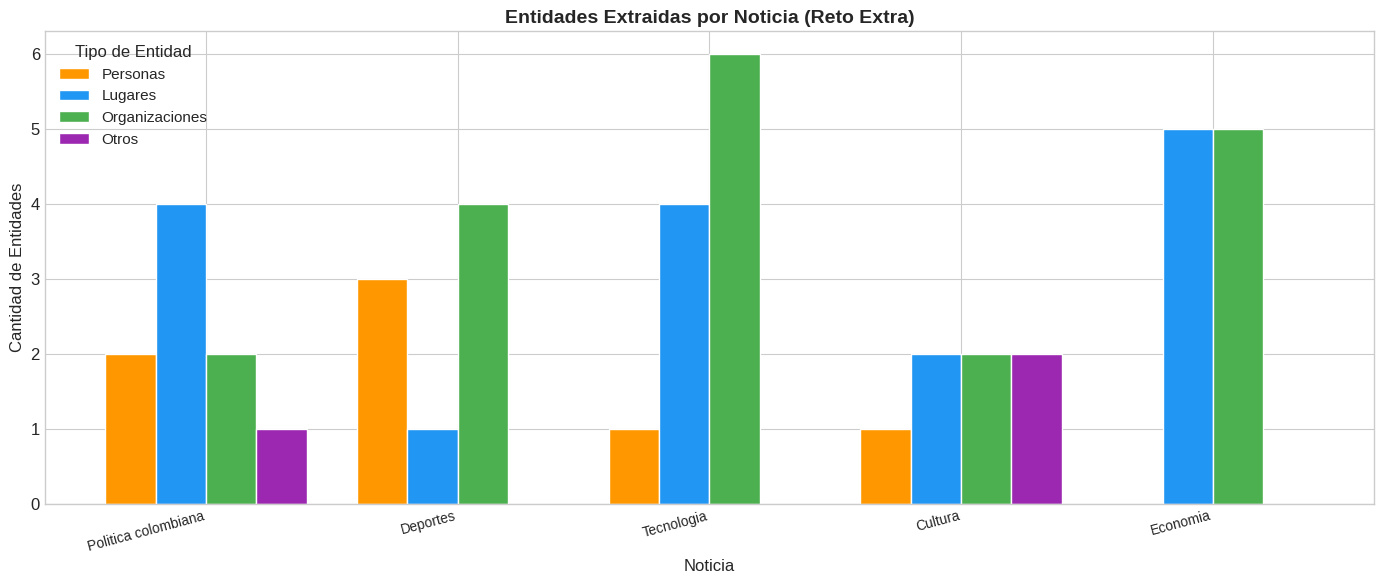


Sistema de extraccion de informacion completado exitosamente


In [66]:
# Crear tabla resumen consolidada con pandas
print("\n" + "=" * 80)
print("TABLA RESUMEN CONSOLIDADA")
print("=" * 80)

filas_tabla = []
for noticia in noticias_prueba:
    info = extraer_informacion(noticia['texto'], modelo_ner)
    fila = {
        'Noticia': noticia['titulo'].split(': ')[1] if ': ' in noticia['titulo'] else noticia['titulo'],
        'Personas': ', '.join(info.get('Personas (PER)', [])) or '-',
        'Lugares': ', '.join(info.get('Lugares (LOC)', [])) or '-',
        'Organizaciones': ', '.join(info.get('Organizaciones (ORG)', [])) or '-',
        'Otros': ', '.join(info.get('Otros (MISC)', [])) or '-',
        'Total': sum(len(v) for v in info.values())
    }
    filas_tabla.append(fila)

df_resumen = pd.DataFrame(filas_tabla)
print(df_resumen.to_string(index=False))

# Visualizacion
fig, ax = plt.subplots(figsize=(14, 6))

categorias = ['Personas', 'Lugares', 'Organizaciones', 'Otros']
colores_cat = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0']
x = np.arange(len(df_resumen))
ancho = 0.2

for j, (cat, color) in enumerate(zip(categorias, colores_cat)):
    valores = []
    for fila in filas_tabla:
        n = len(fila[cat].split(', ')) if fila[cat] != '-' else 0
        valores.append(n)
    offset = ancho * j
    barras = ax.bar(x + offset, valores, ancho, label=cat, color=color, edgecolor='white')

ax.set_xlabel('Noticia', fontsize=12)
ax.set_ylabel('Cantidad de Entidades', fontsize=12)
ax.set_title('Entidades Extraidas por Noticia (Reto Extra)', fontsize=14, fontweight='bold')
ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels([f['Noticia'] for f in filas_tabla], fontsize=10, rotation=15, ha='right')
ax.legend(title='Tipo de Entidad', fontsize=11)

plt.tight_layout()
plt.show()

print("\nSistema de extraccion de informacion completado exitosamente")

---
## 7. Referencias y Recursos Adicionales

### Articulos Fundamentales
1. **Radford et al. (2019)** - *"Language Models are Unsupervised Multitask Learners"* - Paper original de GPT-2. [OpenAI Blog](https://openai.com/research/better-language-models)
2. **Devlin et al. (2018)** - *"BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding"* - Paper original de BERT. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
3. **Holtzman et al. (2019)** - *"The Curious Case of Neural Text Degeneration"* - Paper de Nucleus Sampling (top-p). [arXiv:1904.09751](https://arxiv.org/abs/1904.09751)
4. **Sang & De Meulder (2003)** - *"Introduction to the CoNLL-2003 Shared Task"* - Paper fundacional de NER. [ACL Anthology](https://aclanthology.org/W03-0419/)

### Documentacion Tecnica
5. **Hugging Face - Text Generation** - Documentacion de pipelines de generacion. [huggingface.co/docs/transformers/main_classes/text_generation](https://huggingface.co/docs/transformers/main_classes/text_generation)
6. **Hugging Face - Token Classification (NER)** - Documentacion de NER. [huggingface.co/docs/transformers/task_summary#token-classification](https://huggingface.co/docs/transformers/task_summary)
7. **Hugging Face - GPT2 en espanol** - Modelo utilizado. [huggingface.co/datificate/gpt2-small-spanish](https://huggingface.co/datificate/gpt2-small-spanish)
8. **Hugging Face - BERT NER espanol** - Modelo utilizado. [huggingface.co/mrm8488/bert-spanish-cased-finetuned-ner](https://huggingface.co/mrm8488/bert-spanish-cased-finetuned-ner)

### Recursos Educativos
9. **Jurafsky & Martin** - *"Speech and Language Processing"*, Cap. 8: Sequence Labeling for Parts of Speech and Named Entities. [web.stanford.edu/~jurafsky/slp3/8.pdf](https://web.stanford.edu/~jurafsky/slp3/8.pdf)
10. **Jay Alammar** - *"The Illustrated GPT-2"* - Visualizacion de GPT-2. [jalammar.github.io/illustrated-gpt2](https://jalammar.github.io/illustrated-gpt2/)

### Para la Proxima Guia
- **Guia 14 (ultima):** Etica en Inteligencia Artificial - Sesgos, equidad, privacidad, transparencia y responsabilidad en modelos de lenguaje.

---
*Guia 13 de 14 | Electiva II - Deep Learning | Tecnologico de Antioquia | 2026-1*